# I. Importation of librairies and dataset

## 1. Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## 2. Dataset

In [6]:
df = pd.read_csv('train.csv')

In [7]:
df.rename(columns={'is_churned': 'is_inactive'}, inplace=True)

# II. Dataset analysis

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
None


## 1. Number of columns/rows

In [9]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (165034, 14)
Rows: 165034, Columns: 14


## 2. Number of values

In [10]:
# Basic statistics
print(df.describe())

                id    CustomerId    CreditScore            Age         Tenure  \
count  165034.0000  1.650340e+05  165034.000000  165034.000000  165034.000000   
mean    82516.5000  1.569201e+07     656.454373      38.125888       5.020353   
std     47641.3565  7.139782e+04      80.103340       8.867205       2.806159   
min         0.0000  1.556570e+07     350.000000      18.000000       0.000000   
25%     41258.2500  1.563314e+07     597.000000      32.000000       3.000000   
50%     82516.5000  1.569017e+07     659.000000      37.000000       5.000000   
75%    123774.7500  1.575682e+07     710.000000      42.000000       7.000000   
max    165033.0000  1.581569e+07     850.000000      92.000000      10.000000   

             Balance  NumOfProducts      HasCrCard  IsActiveMember  \
count  165034.000000  165034.000000  165034.000000   165034.000000   
mean    55478.086689       1.554455       0.753954        0.497770   
std     62817.663278       0.547154       0.430707        0.

In [11]:
# Categorical variables summary
categorical_cols = ['Surname', 'Geography', 'Gender']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Surname:
Surname
Hsia         2456
T'ien        2282
Hs?          1611
Maclean      1577
Kao          1577
             ... 
Topp            1
Blacklock       1
McDaniels       1
McMinn          1
Elkins          1
Name: count, Length: 2797, dtype: int64

Geography:
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender:
Gender
Male      93150
Female    71884
Name: count, dtype: int64


## 3. Variables definition

In [12]:
print(df.dtypes)

id                   int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object


In [13]:
print(df.head())

   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   
3   3    15741417             Kao          581    France   Male  34.0       2   
4   4    15766172       Chiemenam          716     Spain   Male  33.0       5   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              2        1.0             0.0        181449.97   
1       0.00              2        1.0             1.0         49503.50   
2       0.00              2        1.0             0.0        184866.69   
3  148882.54              1        1.0             1.0         84560.88   
4       0.00              2        1.0             1.0         15068.83   

   Exited  
0       0  
1       0  
2       0  
3       0  
4 

## 4. Quality

The following cell is using the dataset 'train' which contains approximately 165 000 lines (way more than our first one)

In [14]:
# Data range and potential outliers
numeric_cols = ['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

    # Check for potential outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  Potential outliers: {len(outliers)}")


id:
  Min: 0, Max: 165033
  Mean: 82516.50, Median: 82516.5
  Potential outliers: 0

CustomerId:
  Min: 15565701, Max: 15815690
  Mean: 15692005.02, Median: 15690169.0
  Potential outliers: 0

CreditScore:
  Min: 350, Max: 850
  Mean: 656.45, Median: 659.0
  Potential outliers: 253

Age:
  Min: 18.0, Max: 92.0
  Mean: 38.13, Median: 37.0
  Potential outliers: 6394

Tenure:
  Min: 0, Max: 10
  Mean: 5.02, Median: 5.0
  Potential outliers: 0

Balance:
  Min: 0.0, Max: 250898.09
  Mean: 55478.09, Median: 0.0
  Potential outliers: 0

NumOfProducts:
  Min: 1, Max: 4
  Mean: 1.55, Median: 2.0
  Potential outliers: 475

HasCrCard:
  Min: 0.0, Max: 1.0
  Mean: 0.75, Median: 1.0
  Potential outliers: 40606

IsActiveMember:
  Min: 0.0, Max: 1.0
  Mean: 0.50, Median: 0.0
  Potential outliers: 0

EstimatedSalary:
  Min: 11.58, Max: 199992.48
  Mean: 112574.82, Median: 117948.0
  Potential outliers: 0

Exited:
  Min: 0, Max: 1
  Mean: 0.21, Median: 0.0
  Potential outliers: 34921


The following cell needs to be run if we use our first dataset with 10 000 lines

In [15]:
# # Data range and potential outliers
# numeric_cols = ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
# for col in numeric_cols:
#     print(f"\n{col}:")
#     print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
#     print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

#     # Check for potential outliers using IQR method
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
#     print(f"  Potential outliers: {len(outliers)}")

## 5. Visualization

In [16]:
plt.style.use('default')
sns.set_palette("husl")

### i. Variables distributions

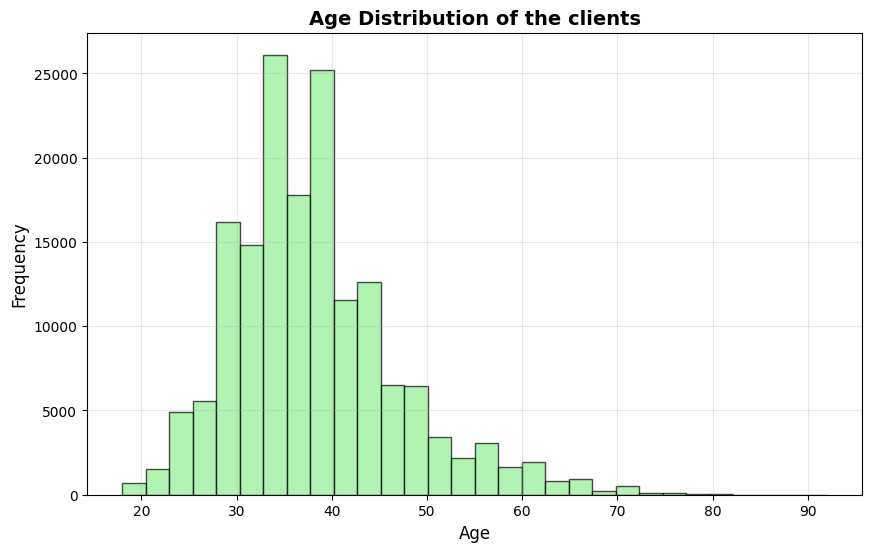

Age statistics:
Min: 18.0, Max: 92.0, Mean: 38.1, Median: 37.0


In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.title('Age Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Age statistics:\nMin: {df['Age'].min()}, Max: {df['Age'].max()}, Mean: {df['Age'].mean():.1f}, Median: {df['Age'].median()}")

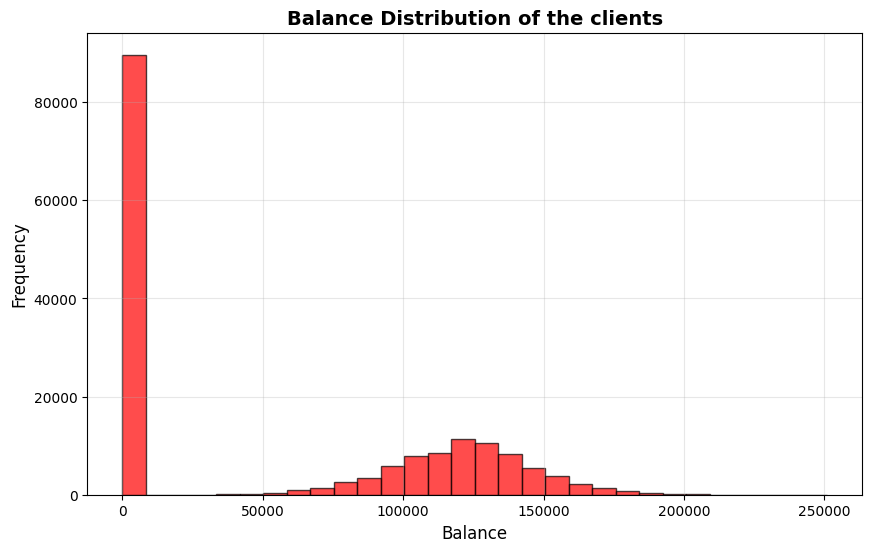

Balance statistics:
Min: 0.0, Max: 250898.09, Mean: 55478.1, Median: 0.0


In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df['Balance'], bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title('Balance Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Balance statistics:\nMin: {df['Balance'].min()}, Max: {df['Balance'].max()}, Mean: {df['Balance'].mean():.1f}, Median: {df['Balance'].median()}")

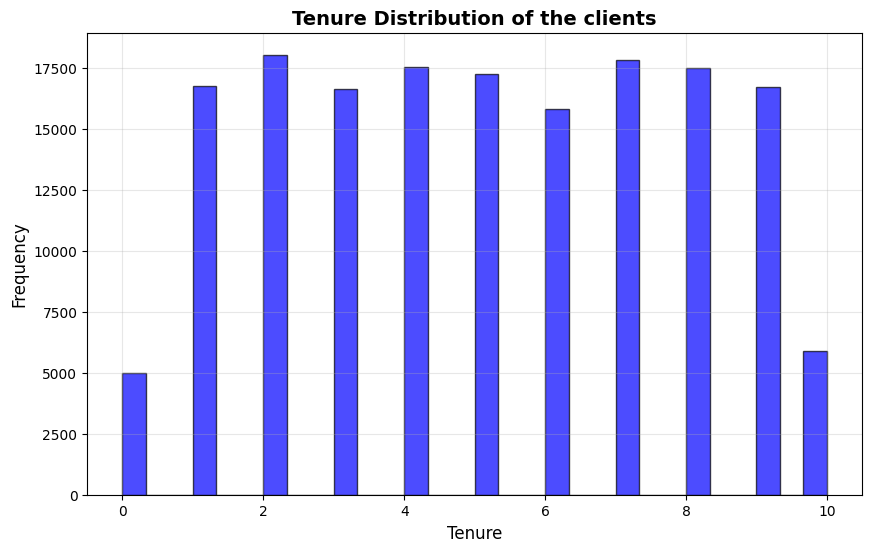

Tenure statistics:
Min: 0, Max: 10, Mean: 5.0, Median: 5.0


In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df['Tenure'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Tenure Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Tenure statistics:\nMin: {df['Tenure'].min()}, Max: {df['Tenure'].max()}, Mean: {df['Tenure'].mean():.1f}, Median: {df['Tenure'].median()}")

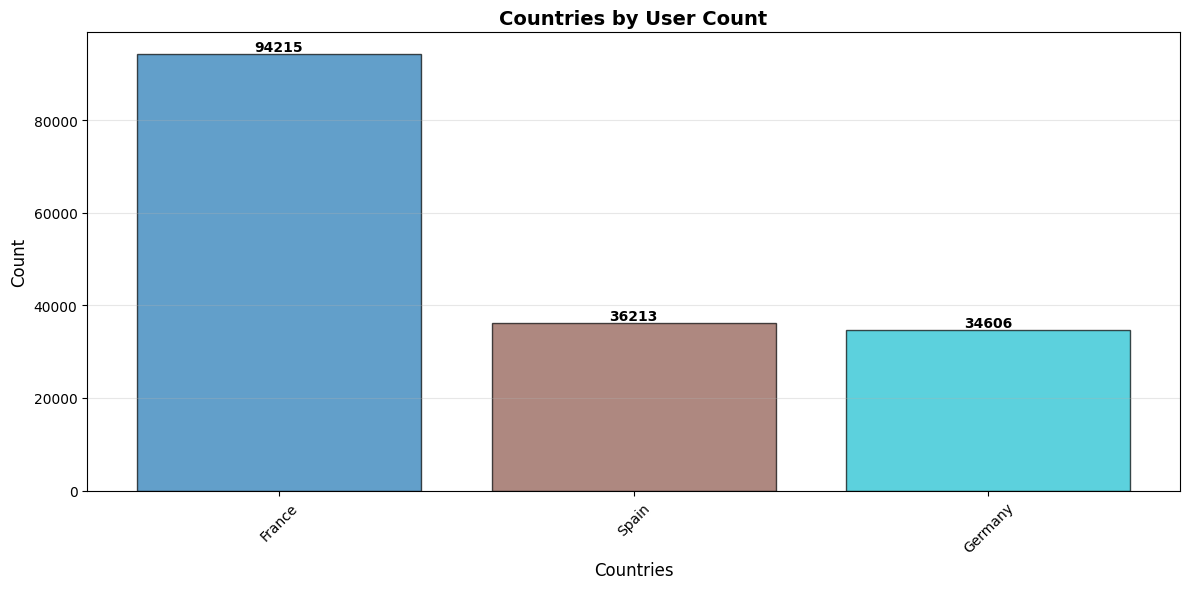

In [20]:
plt.figure(figsize=(12, 6))
country_counts = df['Geography'].value_counts()
colors = plt.cm.tab10(np.linspace(0, 1, len(country_counts)))
plt.bar(country_counts.index, country_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Countries by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Countries', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

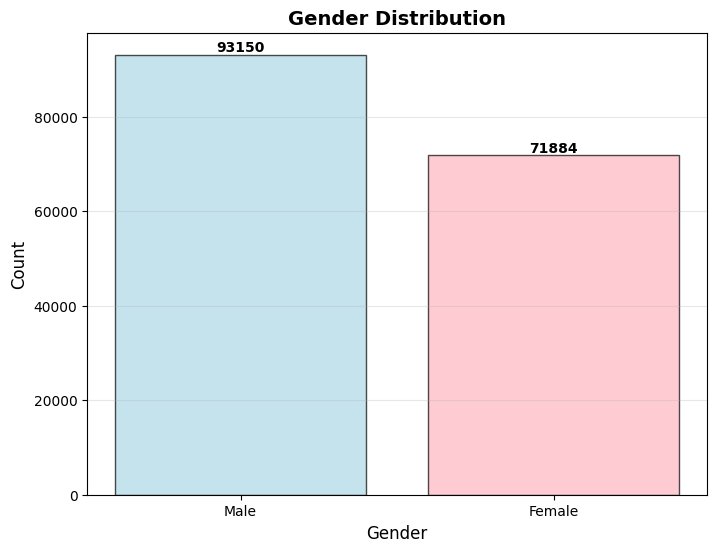

In [21]:
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
colors = ['lightblue', 'lightpink', 'lightgray']
plt.bar(gender_counts.index, gender_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

### ii. exited (Target Variable) distribution by different variables

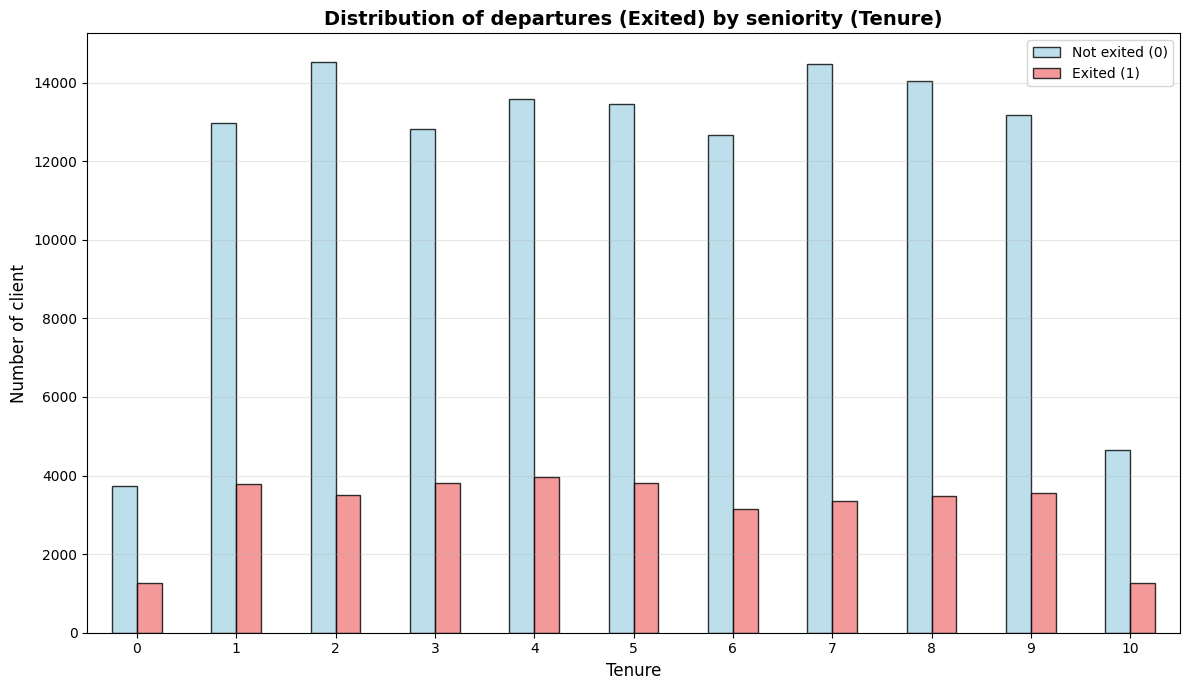

In [22]:
tenure_churn_crosstab = pd.crosstab(df['Tenure'], df['Exited'])

tenure_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by seniority (Tenure)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Number of client', fontsize=12)

plt.legend(['Not exited (0)', 'Exited (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

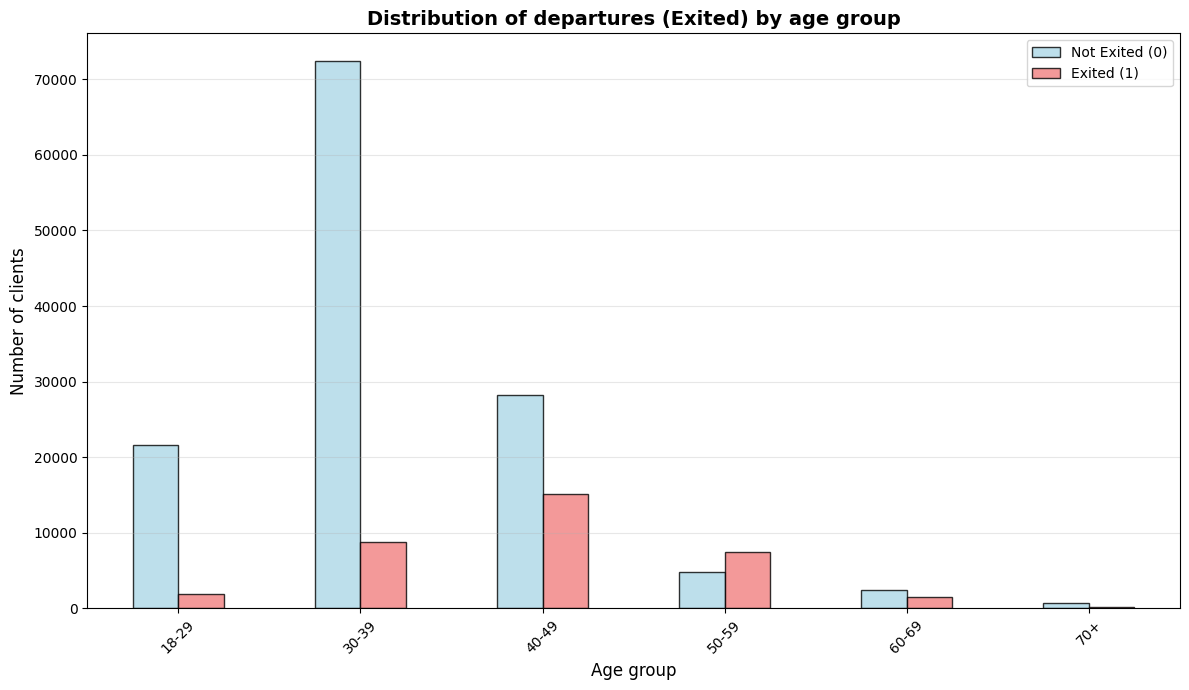

In [23]:
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_churn_crosstab = pd.crosstab(df['AgeGroup'], df['Exited'])

age_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by age group', fontsize=14, fontweight='bold')
plt.xlabel('Age group', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend(['Not Exited (0)', 'Exited (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

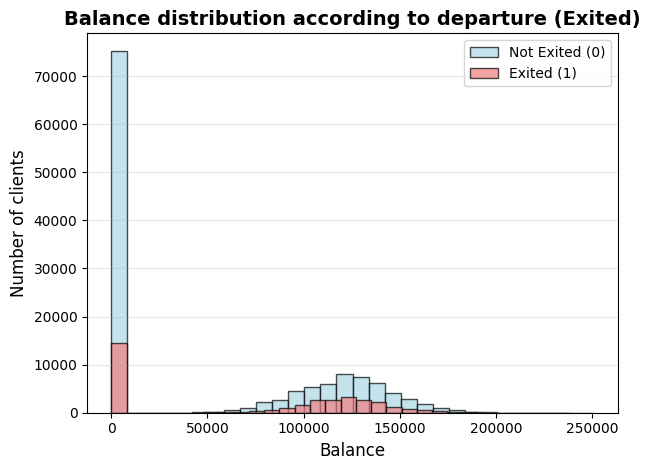

In [24]:
plt.hist(
    df[df['Exited'] == 0]['Balance'],
    bins=30,
    alpha=0.7,
    label='Not Exited (0)',
    color='lightblue',
    edgecolor='black'
)

plt.hist(
    df[df['Exited'] == 1]['Balance'],
    bins=30,
    alpha=0.7,
    label='Exited (1)',
    color='lightcoral',
    edgecolor='black'
)

plt.title('Balance distribution according to departure (Exited)', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

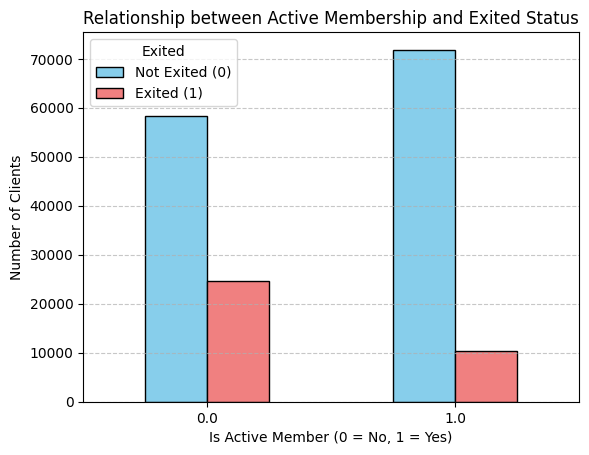

In [25]:
active_exited = df.groupby("IsActiveMember")["Exited"].value_counts().unstack().fillna(0)

active_exited.plot(kind="bar", color=["skyblue", "lightcoral"], edgecolor="black")

plt.title("Relationship between Active Membership and Exited Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")
plt.legend(["Not Exited (0)", "Exited (1)"], title="Exited")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


## 6. Correlation analysis

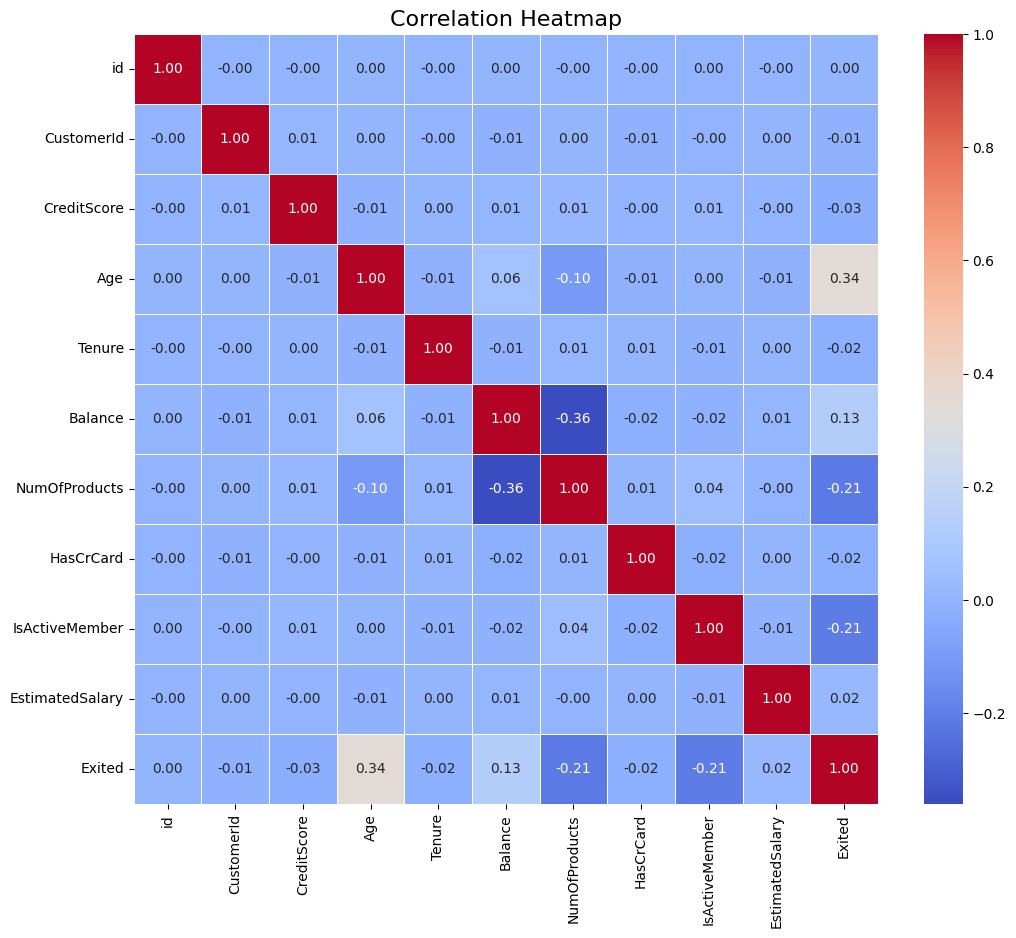

In [26]:
target_col = 'Exited'

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [27]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited             1.000000
Age                0.340768
NumOfProducts      0.214554
IsActiveMember     0.210237
Balance            0.129743
CreditScore        0.027383
HasCrCard          0.022141
Tenure             0.019565
EstimatedSalary    0.018827
CustomerId         0.009947
id                 0.002512
Name: Exited, dtype: float64


## 7. Data balance

In [28]:
class_counts = df['Exited'].value_counts()
print("Class distribution:\n", class_counts)

minority = class_counts.min()
majority = class_counts.max()
ratio = majority / minority
print(f"Imbalance ratio ≈ 1:{ratio:.2f}")

Class distribution:
 Exited
0    130113
1     34921
Name: count, dtype: int64
Imbalance ratio ≈ 1:3.73


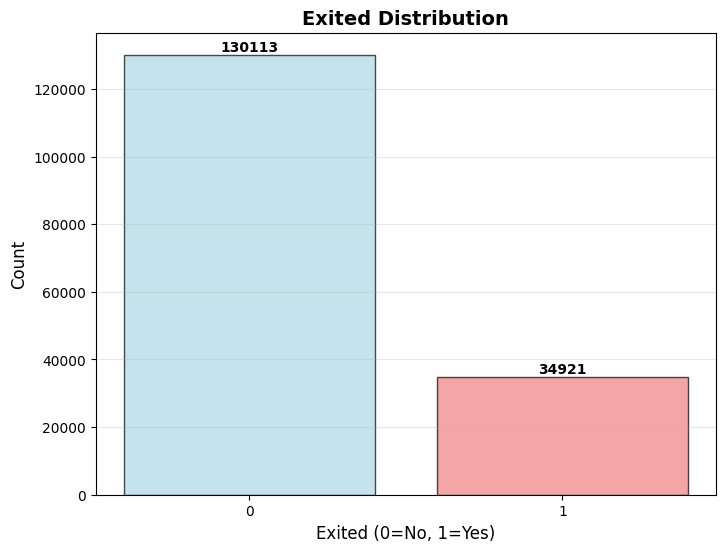

Exited rate: 21.2%


In [29]:
# Target variable distribution
plt.figure(figsize=(8, 6))
inactive_counts = df['Exited'].value_counts()
colors = ['lightblue', 'lightcoral']
plt.bar(inactive_counts.index, inactive_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Exited Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1])
for i, v in enumerate(inactive_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Exited rate: {inactive_counts[1] / len(df) * 100:.1f}%")

This imbalance is not extreme (an extreme imbalance is generally around 1:10, as in fraud detection). However, it is significant enough to require specific attention, because:

- Model Bias: A default model could achieve an Accuracy of 79.5% by simply predicting that no one will inactive. It might completely ignore the minority class, which is unacceptable for a inactive prediction objective.

- Business Objective: The minority class (exited) is the main class of interest (the one the company wants to predict and prevent). Our model must excel at correctly identifying these at-risk users.

**To fix this problem, we are going to use the SMOTE later**

# III. Data pre-processing

## 1. Missing values

In [30]:
missing_values = df.isnull().sum()
print(missing_values)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
AgeGroup           0
dtype: int64


In [31]:
df_clean = df.dropna()

print(f"Original size: {len(df)}")
print(f"Size cleaned: {len(df_clean)}")
print(f"Deleted lines: {len(df) - len(df_clean)}")

Original size: 165034
Size cleaned: 165034
Deleted lines: 0


## 2. Duplicates

In [32]:
if df_clean.duplicated().sum() > 0:
    print(df_clean[df_clean.duplicated(keep=False)])
    print(f"Duplicate rows found: {df.duplicated().sum()}")
else:
    print(" No duplicate rows found")

 No duplicate rows found


In [33]:
id_cols = ['RowNumber', 'CustomerId', 'Surname']

feature_cols = [col for col in df_clean.columns if col not in id_cols]

duplicates = df_clean.duplicated(subset=feature_cols).sum()

if duplicates > 0:
    print(f"Duplicate entries found: {duplicates}")

    df_final = df_clean.drop_duplicates(subset=feature_cols, keep='first')

    print(f"Size before deletion: {len(df_clean)}")
    print(f"Size after deletion: {len(df_final)}")

else:
    print("No duplicate entries found.")
    df_final = df_clean.copy()

No duplicate entries found.


In [34]:
df = df_clean

## 3. Inconsistencies

In [35]:
print("Unique values ​​for 'Geography':")
print(df['Geography'].unique())

print("\nUnique values ​​for 'Gender':")
print(df['Gender'].unique())

Unique values ​​for 'Geography':
['France' 'Spain' 'Germany']

Unique values ​​for 'Gender':
['Male' 'Female']


No Inconsistencies here, and we didn't saw any other since the beginning of the work

## 4. Feature Engineering

**Let's create some new interesting features**  
This was not asked in the instructions but it can be really helpful to help our future models to understand better the datas and improve our results.

We clearly saw before that there are a lot of customers with a 0 balance

In [36]:
balance_zero = df[df['Balance'] == 0]
print(f"\nNumber of customers with a balance of 0: {len(balance_zero)}")

if len(balance_zero) > 0:
    churn_rate_without_balance = balance_zero['Exited'].value_counts(normalize=True)
    print("Percentage of 'Exited' customers with a 0 balance:")
    # Access the percentage for 'Exited' (index 1) and format it
    print(f"{churn_rate_without_balance.get(1, 0):.2%}")


Number of customers with a balance of 0: 89648
Percentage of 'Exited' customers with a 0 balance:
16.17%


In [37]:
clients_with_balance = df[df['Balance'] > 0]
churn_rate_with_balance = clients_with_balance['Exited'].mean()

print(f"'Exited' rate for customers with balance > 0: {churn_rate_with_balance:.2%}")

churn_rate_global = df['Exited'].mean()
print(f"Overall 'Exited' Rate: {churn_rate_global:.2%}")

'Exited' rate for customers with balance > 0: 27.10%
Overall 'Exited' Rate: 21.16%


In [38]:
df_model = df.copy()

# Create a 'IsZeroBalance' feature
# 1 if the balance is 0, 0 otherwise
df_model['IsZeroBalance'] = (df_model['Balance'] == 0).astype(int)

print(df_model[['Balance', 'IsZeroBalance']].head(10))

     Balance  IsZeroBalance
0       0.00              1
1       0.00              1
2       0.00              1
3  148882.54              0
4       0.00              1
5  131778.58              0
6  144772.69              0
7  138476.41              0
8       0.00              1
9   81274.33              0


Let's say customer A and B have a tenure equal to 5 years
- Customer A (25 years old) is a very loyal customer. They have been a customer for a significant portion of their adult life.

- Customer B (60 years old) is a very recent customer. They joined you only 5 years ago, perhaps after spending 35 years changing of bank every 5 years.

These two customers are radically different, but the model, simply seeing Tenure = 5, will struggle to grasp this nuance.

In [39]:
df_model['TenurePerAge'] = df_model['Tenure'] / (df_model['Age'] + 1) # +1 to avoid division by zero if the age is 0

- For Client A: This €100,000 balance represents two full years of their salary. It's likely their entire savings. They are extremely invested in this bank. Losing this client would be a serious loss.

- For Client B: This €100,000 balance represents only six months of their salary (or 0.5 times). For this high-income client, it might just be a temporary account or spending money. They may be less focused on the service, but also much less loyal because their main assets are elsewhere.

Unfortunately this maybe not working because the feature is an "Estimated Salary"

In [40]:
df_model['BalancePerSalary'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1e-6) # +1e-6 to avoid division by zero if the salary is 0

In [41]:
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df_model['AgeGroup'] = pd.cut(df_model['Age'], bins=bins, labels=labels, right=False)

print("\nChurn Rate by Age Group:")
print(df_model.groupby('AgeGroup')['Exited'].mean())


Churn Rate by Age Group:
AgeGroup
18-29    0.083539
30-39    0.108291
40-49    0.348000
50-59    0.609388
60+      0.349009
Name: Exited, dtype: float64


C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\3261978172.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby('AgeGroup')['Exited'].mean())


**Let's see if our Feature Engineering worked or not**

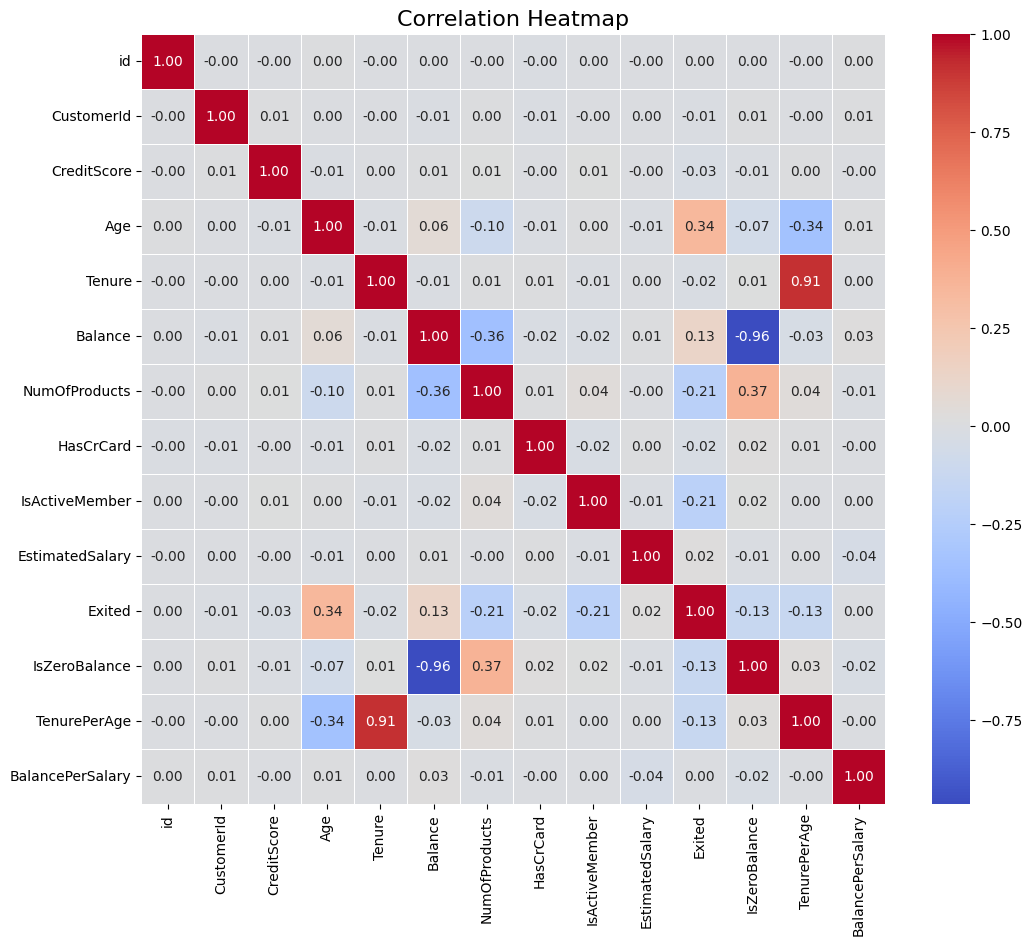

In [42]:
target_col = 'Exited'

numerical_columns = df_model.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [43]:
numeric_df = df_model.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited              1.000000
Age                 0.340768
NumOfProducts       0.214554
IsActiveMember      0.210237
IsZeroBalance       0.133346
Balance             0.129743
TenurePerAge        0.128395
CreditScore         0.027383
HasCrCard           0.022141
Tenure              0.019565
EstimatedSalary     0.018827
CustomerId          0.009947
id                  0.002512
BalancePerSalary    0.001559
Name: Exited, dtype: float64


We can see that some of our new features have a high correlation with our target feature ! Our work should help then !

In [44]:
df = df_model

In [45]:
df.drop(columns=['Age'], inplace=True)

## 5. Outliers

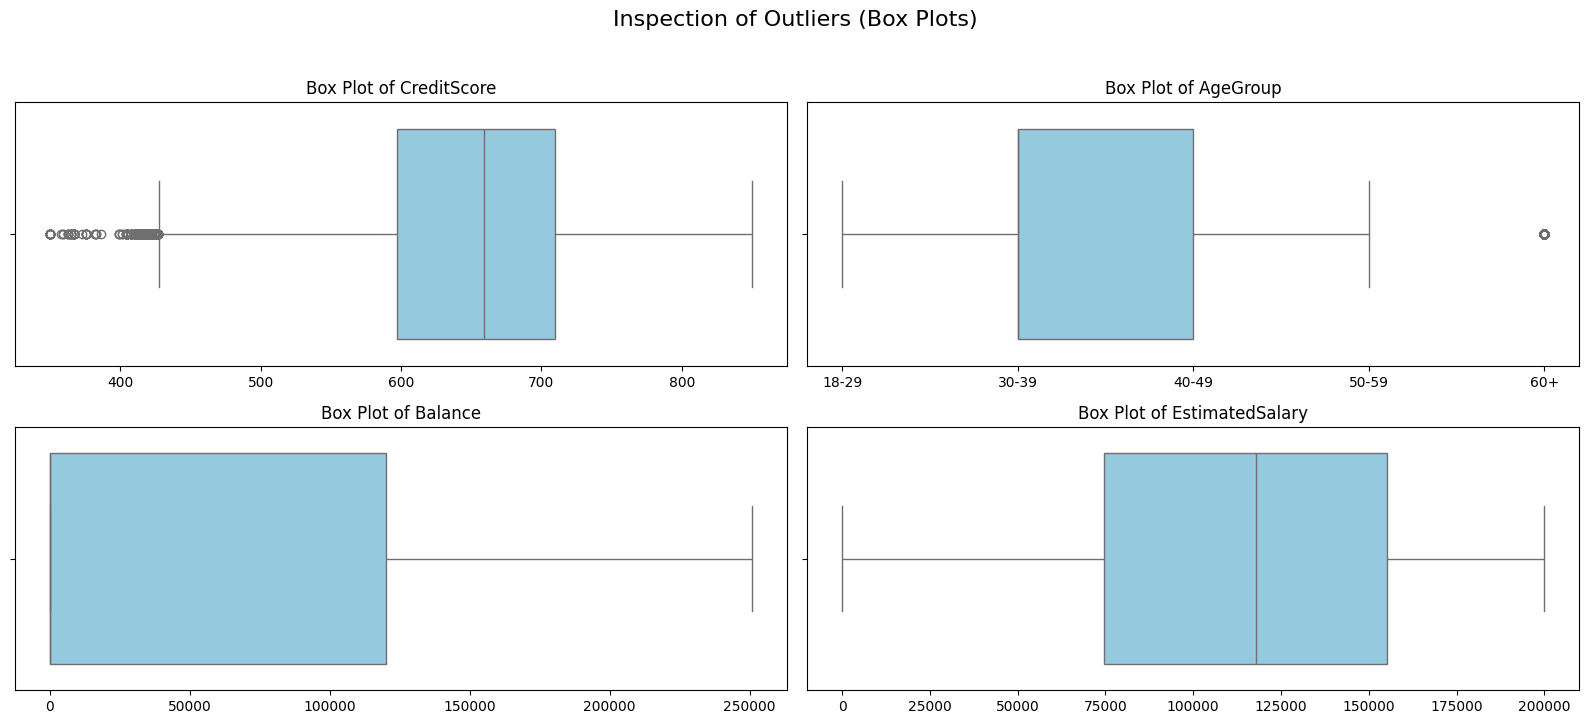

In [46]:
cols_to_check = ['CreditScore', 'AgeGroup', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(16, 10))
plt.suptitle('Inspection of Outliers (Box Plots)', fontsize=16, y=1.02)

for i, col in enumerate(cols_to_check):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

We don't think that we need to remove the outliers because in this case the outliers are giving some insights about data. But we tested to remove them to validate our theory, and it proved that we were right. Here is the commented code to remove outliers.

In [47]:
# Q1 = df['CreditScore'].quantile(0.25)
# Q3 = df['CreditScore'].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR

# upper_bound = Q3 + 1.5 * IQR

# print(f"Lower Bound for CreditScore: {lower_bound}")
# print(f"Upper Bound for CreditScore: {upper_bound}")

# df_cleaned = df[
#     (df['CreditScore'] >= lower_bound) & 
#     (df['CreditScore'] <= upper_bound)
# ]

# print(f"\nOriginal shape: {df.shape}")
# print(f"New shape:      {df_cleaned.shape}")
# print(f"Rows removed:   {df.shape[0] - df_cleaned.shape[0]}")

In [48]:
# df = df_cleaned.copy()

## 6. Encoding, Scaling, Train-test-Split

In [49]:
print(df.groupby('NumOfProducts')['Exited'].mean())

NumOfProducts
1    0.347119
2    0.060422
3    0.882516
4    0.875789
Name: Exited, dtype: float64


C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\3867555604.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')


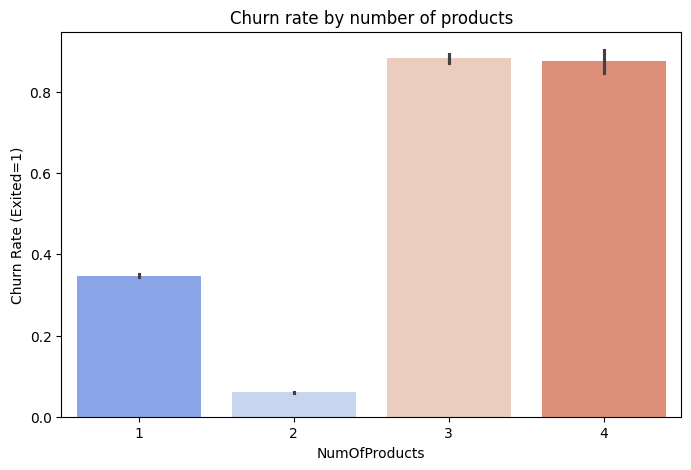

In [50]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')
plt.title('Churn rate by number of products')
plt.ylabel('Churn Rate (Exited=1)')
plt.show()

Here we need to use the One-Hot encoding for this features, but also for those: 'Geography', 'Gender', 'AgeGroup'

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
categorical_features = ['NumOfProducts', 'AgeGroup', 'Geography', 'Gender']
numeric_features = ['CreditScore', 'Tenure', 'Balance', 'EstimatedSalary', 'TenurePerAge', 'BalancePerSalary']

In [53]:
y = df['Exited']
X = df.drop(columns=['Exited', 'id', 'CustomerId', 'Surname'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for the test
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,      # 25% of 80% = 20% of the total
    random_state=42,
    stratify=y_train_val
)

The following cell need to be run if we us our initial dataset

In [54]:
# y = df['Exited']
# X = df.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname'])

# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y,
#     test_size=0.2,       # 20% for the test
#     random_state=42,
#     stratify=y
# )

# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val,
#     test_size=0.25,      # 25% of 80% = 20% of the total
#     random_state=42,
#     stratify=y_train_val
# )

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'),
         categorical_features),

        ('scale',
         StandardScaler(),
         numeric_features)
    ],
    remainder='drop'
)

In [56]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

encoded_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([encoded_feature_names, numeric_features])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_feature_names)

In [57]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution  AFTER SMOTE (Training Set):")
print(pd.Series(y_train_smote).value_counts())


Class distribution  AFTER SMOTE (Training Set):
Exited
1    78067
0    78067
Name: count, dtype: int64


Here we use the SMOTE algorithms the handle imbalanced data (same as in the TDs)

Here is the list of the data we can use for training:
- Original data:
  - X_train
  - y_train
- Scaled data:
  - X_train_scaled -> scaled data
  - y_train
- SMOTE data:
  - X_train_smote (scaled + SMOTE)
  - y_train_smote (SMOTE only)

Here is the list of the data we can use for validation:
- Original data:
  - X_val
  - y_val
- Scaled data:
  - X_val_scaled
  - y_val
- No SMOTE for the validation

Here is the list of the data we can use for the final test:
- Original data
  - X_test
  - y_test
- Scaled data
  - X_test_scaled
  - y_test
- No SMOTE for the test


# IV. Models

## 1. Fisrt Models

### Logistic Regression

                precision    recall  f1-score   support

Not exited (0)       0.93      0.78      0.85     26023
    Exited (1)       0.49      0.78      0.61      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007



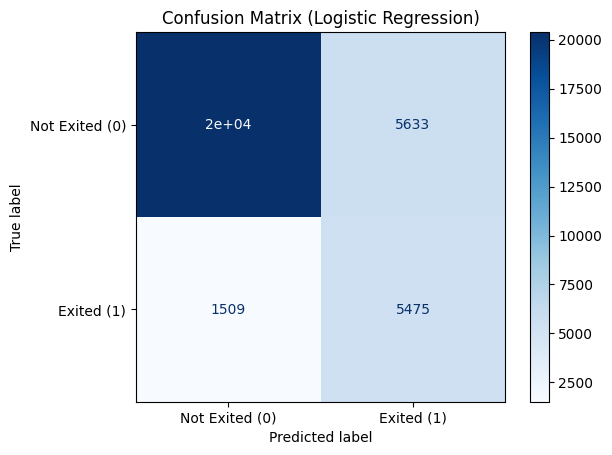

In [58]:
model_lr = LogisticRegression(C=0.1, penalty="l2", solver="lbfgs", max_iter=1000, random_state=42)
# C is the inverse of regularization strength.
# penalty l2 to prevent overfitting

model_lr.fit(X_train_smote, y_train_smote)

y_pred = model_lr.predict(X_val_scaled)

print(classification_report(y_val, y_pred, target_names=['Not exited (0)', 'Exited (1)']))
ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)

plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

### SVM (Support Vector Machine)

In [59]:
from sklearn.svm import SVC

c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:304: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 Classification Report(SVM)
                precision    recall  f1-score   support

Not Exited (0)       1.00      0.00      0.00     26023
    Exited (1)       0.21      1.00      0.35      6984

      accuracy                           0.21     33007
     macro avg       0.61      0.50      0.17     33007
  weighted avg       0.83      0.21      0.07     33007



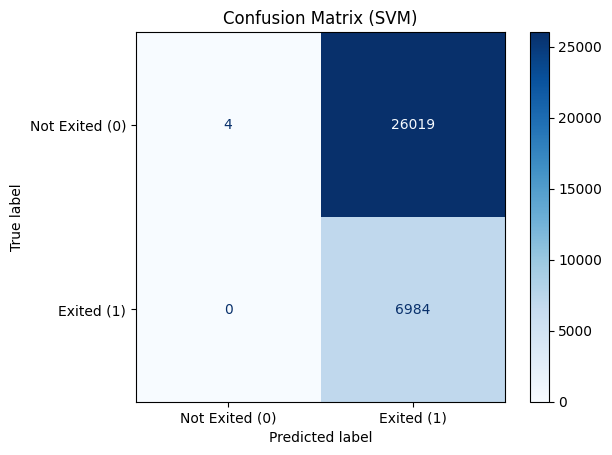

In [60]:
model_svm = SVC(
    C=0.1, 
    kernel='linear', 
    probability=True, 
    max_iter=1000,
    random_state=42
)

model_svm.fit(X_train_smote, y_train_smote)

y_pred_svm = model_svm.predict(X_val_scaled)

print("\n Classification Report(SVM)")
print(classification_report(y_val, y_pred_svm, target_names=['Not Exited (0)', 'Exited (1)']))

ConfusionMatrixDisplay.from_estimator(
    model_svm,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (SVM)')
plt.show()

## 2. Model’s hyperparameter’s tuning

In [61]:
from sklearn.model_selection import GridSearchCV

### Logistic Regression

In [62]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}
# Smaller values (0.001) specify stronger regularization (prevent overfitting).
# Larger values (100) specify weaker regularization (fit training data better).
# We use a logarithmic scale to cover a broad range of possibilities.

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_lr.fit(X_train_smote, y_train_smote)

print("\nBest parameters for Logistic Regression:")
print(grid_lr.best_params_)

print("\nClassification Report (Tuned LR)")
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred_lr_tuned, target_names=['Not exited (0)', 'Exited (1)']))

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best parameters for Logistic Regression:
{'C': 100}

Classification Report (Tuned LR)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.78      0.85     26023
    Exited (1)       0.49      0.78      0.61      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007



In [63]:
param_grid_svm = {
    'C': [0.01, 0.1, 0.5, 1, 10]
}
# For SVM, C trades off misclassification of training examples against simplicity of the decision surface.
# A low C makes the decision surface smooth, while a high C aims to classify all training examples correctly.
# We stick to lower values to avoid overfitting given the noise in customer behavior.

grid_svm = GridSearchCV(
    SVC(kernel='linear', probability=True, max_iter=1000, random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=2,
    verbose=3,
    n_jobs=-1
)

grid_svm.fit(X_train_smote, y_train_smote)

print("\nBest settings for the SVM:")
print(grid_svm.best_params_)

print("\nClassification Report (Tuned SVM)")
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_val_scaled)
print(classification_report(y_val, y_pred_svm_tuned, target_names=['Not Exited (0)', 'Exited (1)']))

Fitting 2 folds for each of 5 candidates, totalling 10 fits


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:304: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best settings for the SVM:
{'C': 1}

Classification Report (Tuned SVM)
                precision    recall  f1-score   support

Not Exited (0)       0.79      0.46      0.58     26023
    Exited (1)       0.21      0.55      0.31      6984

      accuracy                           0.48     33007
     macro avg       0.50      0.50      0.44     33007
  weighted avg       0.67      0.48      0.52     33007



Here we can see that the recall and the f1-score collapsed compared to earlier. This is due to overfitting, so let's move to the next step

# V. Obstacles

## 1. Overfitting

In [64]:
from sklearn.metrics import f1_score

y_pred_lr_train = model_lr.predict(X_train_smote)
y_pred_lr_tuned = best_lr.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_lr_train)
f1_val = f1_score(y_val, y_pred_lr_tuned)

print(f"F1-Score (Training LR): {f1_train:.2f}")
print(f"F1-Score (Validation LR): {f1_val:.2f}")

F1-Score (Training LR): 0.79
F1-Score (Validation LR): 0.61


In [65]:
y_pred_svm_train = model_svm.predict(X_train_smote)
y_pred_svm_tuned = model_svm.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_svm_train)
f1_val = f1_score(y_val, y_pred_svm_tuned)

print(f"F1-Score (Training SVM): {f1_train:.2f}")
print(f"F1-Score (Validation SVM): {f1_val:.2f}")

F1-Score (Training SVM): 0.67
F1-Score (Validation SVM): 0.35


We understand that both models are overfitting. Overfitting is going to be a major problem in our project. We are going to verify for each model its overfitting and try to avoid it as much as we can

Every model created in the next part will be created following the nexts steps:
1. Defining a basic model with 'classic' parameters anti-overfitting (based on research we tried to implement every model with 'good' parameters that avoid overfitting as best as a model can)  

2. Trying to optimize it, principaly with gridsearchs (we are going to use Cross validation in order to counter overfitting in gridsearchs (cv=3 to win some time compare to cv=5))

## 2. Underfitting

It appears that there is no underfitting

## 3. Data Leakage

It appears that there is not data leakage.  
- Data leakage is when we use a feature that will not be available at the time we will make the prediction. For example if we had a feature like 'churn_date' it will be data leak to use it to predict if the customer will churn or no.  
- We also could have a pipeline leakage but we created the train/val/test (+ scaler/SMOTE, etc.) with a particular attention and there is not such thing

# VI. Relevant Metrics

**Our strategy**

The standard metrics for optimizing an imbalanced model are F-scores or Area Under the Precision-Recall Curve (PR-AUC).  
The F-beta score (a generalized F-score) is the perfect choice because it allows us to explicitly weight Recall versus Precision:
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$
If $\beta = 1$ (F1-score): Gives equal importance to Precision and Recall.
If $\beta < 1$ (e.g., $F_{0.5}$): Gives more weight to Precision (minimizing False Positives).  
If $\beta > 1$ (e.g., $F_{2}$): Gives more weight to Recall (minimizing False Negatives).  
Since our current model has a slightly lower Recall than a potential target, and we want to ensure that we capture the minority class (which usually means favoring Recall), the $F_2$-score is the best choice.  
$F_2$-score places twice the weight on Recall compared to Precision, ensuring the grid search focuses on finding the positive examples.  
We want indeed to capture the minority class here because we want to maximise the detection of the client that has a high chance to churn to allow a bank to avoid it!

In [66]:
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV

# We define the custom F2-scorer for the gridsearch
# beta=2: weights Recall twice as much as Precision
# pos_label=1: explicitly targets the positive class (class 1)
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

We can analyze the Logistic Regression and the SVM we already did

In [67]:
print(fbeta_score(y_val, model_lr.predict(X_val_scaled), beta=2, pos_label=1))

0.7011320561417888


In [68]:
print(fbeta_score(y_val, best_lr.predict(X_val_scaled), beta=2, pos_label=1))

0.7008172571926319


In [69]:
print(fbeta_score(y_val, model_svm.predict(X_val_scaled), beta=2, pos_label=1))

0.5730320484418845


In [70]:
print(fbeta_score(y_val, best_svm.predict(X_val_scaled), beta=2, pos_label=1))

0.4173937701771224


For all of our model we are only going to "keep" the best one for the comparison plot at the end

In [71]:
model_lr = model_lr
model_svm = model_svm

# VII. Dimension reduction

In [72]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'AgeGroup', 'IsZeroBalance',
       'TenurePerAge', 'BalancePerSalary'],
      dtype='object')

In [73]:
from sklearn.decomposition import PCA

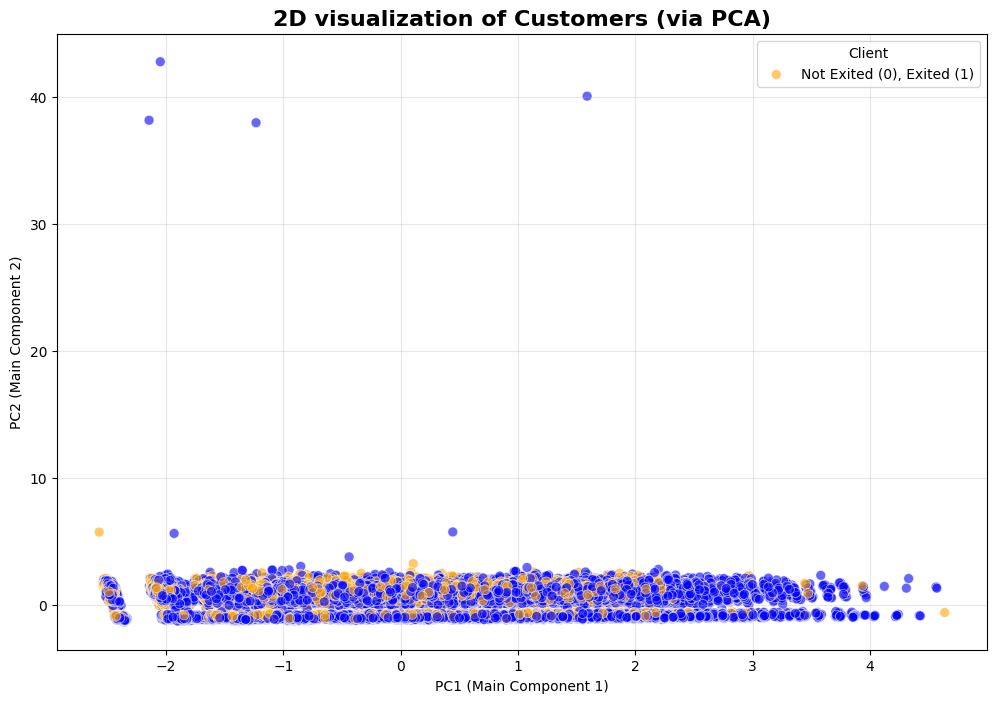

Variance explained by PC1: 26.0%
Variance explained by PC2: 15.1%
Total variance explained by 2 components: 41.1%


In [74]:
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

df_pca_2d = pd.DataFrame(
    data=X_train_pca_2d,
    columns=['PC1 (Main Component 1)', 'PC2 (Main Component 2)']
)

df_pca_2d['Exited'] = y_train.values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca_2d,
    x='PC1 (Main Component 1)',
    y='PC2 (Main Component 2)',
    hue='Exited',
    palette={0: 'blue', 1: 'orange'},
    alpha=0.6,
    s=50
)

plt.title('2D visualization of Customers (via PCA)', fontsize=16, fontweight='bold')
plt.legend(title='Client', labels=['Not Exited (0), Exited (1)'])
plt.grid(alpha=0.3)
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%}")

Here we have the visual confirmation that our problem is not linear and multi-dimensionnal (because we explane only ~40% of the variance with a 2D PCA)

In [75]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

In [76]:
pipe_pca_model = ImblearnPipeline([
    ('preprocessor', preprocessor), # Added the existing ColumnTransformer
    ('pca', PCA(n_components=0.95)), # Here we reject 5% of the information
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_pca_model.fit(X_train, y_train)

y_pred_pca = pipe_pca_model.predict(X_val)

print("\nNumber of² components selected by PCA to retain 95% variance:")
print(pipe_pca_model.named_steps['pca'].n_components_)
print("\nClassification Report (PCA 95%)")
print(classification_report(y_val, y_pred_pca, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_pca, beta=2, pos_label=1))


Number of² components selected by PCA to retain 95% variance:
10

Classification Report (PCA 95%)
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.75      0.83     26023
    Exited (1)       0.45      0.75      0.56      6984

      accuracy                           0.75     33007
     macro avg       0.68      0.75      0.70     33007
  weighted avg       0.82      0.75      0.77     33007


F2-Score
0.6620658273926893


Our F2-score is lower than before. We can conclude that the 5% of the information we rejected was not noise, it was usefull information

# VIII. Advanced Models

## 1. The Tree Models

### Decision Tree

In [77]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

Let's start with a simple tree

In [78]:
model_dt_simple = DecisionTreeClassifier(max_depth=2, random_state=42)

model_dt_simple.fit(X_train_smote, y_train_smote)

y_pred_dt_simple = model_dt_simple.predict(X_val_scaled)

print("\nClassification Report (Simple Tree, max_depth=2)")
print(classification_report(y_val, y_pred_dt_simple, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_dt_simple, beta=2, pos_label=1))


Classification Report (Simple Tree, max_depth=2)
                precision    recall  f1-score   support

Not Exited (0)       0.94      0.61      0.74     26023
    Exited (1)       0.37      0.86      0.52      6984

      accuracy                           0.66     33007
     macro avg       0.65      0.73      0.63     33007
  weighted avg       0.82      0.66      0.69     33007


F2-Score
0.6768474913964861


In [79]:
train_score = fbeta_score(y_train_smote, model_dt_simple.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_dt_simple, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8260
fbeta Val   : 0.6768
Gap   : 0.1491


Overfitting is not "too bad"

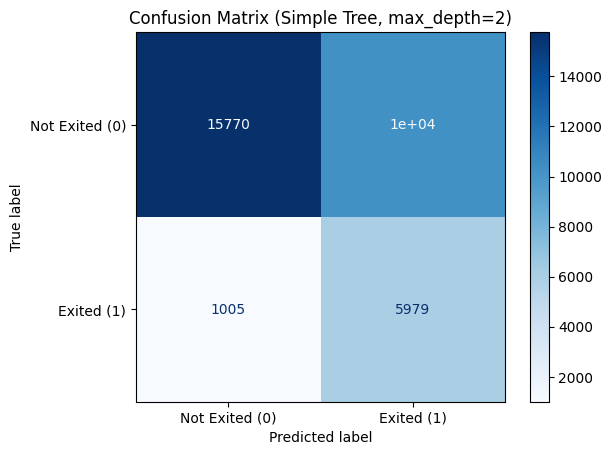

In [80]:
ConfusionMatrixDisplay.from_estimator(
    model_dt_simple,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Simple Tree, max_depth=2)')
plt.show()

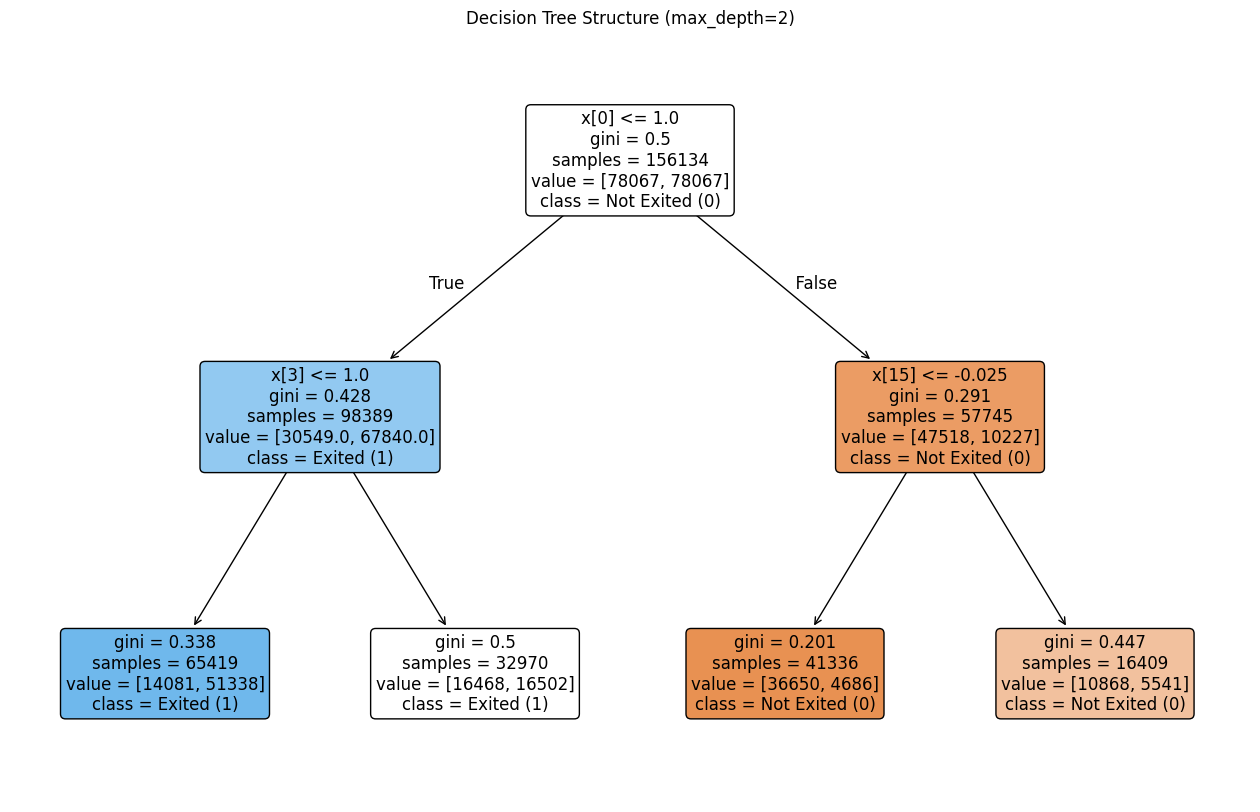

In [81]:
plt.figure(figsize=(16, 10))
plot_tree(
    model_dt_simple,
    filled=True,
    rounded=True,
    class_names=['Not Exited (0)', 'Exited (1)'],
    fontsize=12
)
plt.title('Decision Tree Structure (max_depth=2)')
plt.show()

This very basic model catches a fair number of churners but is not very precise, flagging many clients unnecessarily.

We now try an unlimited depth decision tree :

In [82]:
model_dt_unlimited = DecisionTreeClassifier(random_state=42)

model_dt_unlimited.fit(X_train_smote, y_train_smote)

y_pred_dt_unlimited = model_dt_unlimited.predict(X_val_scaled)

print("\nClassification Report (Unlimited Depth Tree)")
print(classification_report(y_val, y_pred_dt_unlimited, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_dt_unlimited, beta=2, pos_label=1))


Classification Report (Unlimited Depth Tree)
                precision    recall  f1-score   support

Not Exited (0)       0.88      0.82      0.85     26023
    Exited (1)       0.46      0.57      0.51      6984

      accuracy                           0.77     33007
     macro avg       0.67      0.69      0.68     33007
  weighted avg       0.79      0.77      0.78     33007


F2-Score
0.5405849490634242


In [83]:
train_score = fbeta_score(y_train_smote, model_dt_unlimited.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_dt_unlimited, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.9991
fbeta Val   : 0.5406
Gap   : 0.4585


Huge overfitting, this is actually normal because since we have an unlimited depth it means that the Decision Tree continue to train until it gets to highest score possible on the training data which is closed to 1.0 but is overtrain and doesn't explain well the data in reality

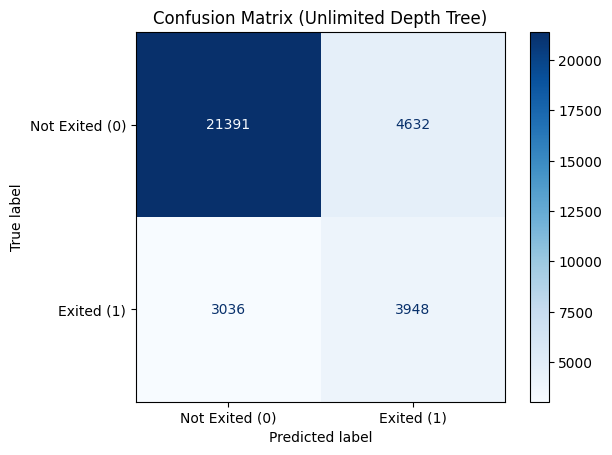

In [84]:
ConfusionMatrixDisplay.from_estimator(
    model_dt_unlimited,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Unlimited Depth Tree)')
plt.show()

While more flexible than the max_depth=2 tree, this model still struggles with F2-score for the churn class and shows signs of overfitting due to its unrestricted depth

Optimizing the Decision Tree

In [85]:
param_grid = {
    'max_depth': list(range(3, 13)),
    # We cap the depth at 12 to prevent the tree from growing too deep and memorizing the noise (overfitting).
    'min_samples_leaf': list(range(5, 51, 5)),
    # This enforces that any terminal node must have at least 5 to 50 samples.
    # Higher values smooth the model, preventing it from isolating single specific clients.
    'criterion': ['gini', 'entropy'],
    # Gini is generally faster; Entropy can sometimes produce slightly more balanced trees. We test both.
    'min_samples_split': [10, 20, 40],
    # The minimum number of samples required to split an internal node.
    # Higher values prevent the tree from learning relations which might be highly specific to the particular sample selected for a tree.
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters found: {grid_search.best_params_}")

Fitting 3 folds for each of 1800 candidates, totalling 5400 fits

Best parameters found: {'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20}


In [86]:
best_dt_model = grid_search.best_estimator_

y_pred_best = best_dt_model.predict(X_val_scaled)

print("\nClassification Report (Optimized Tree)")
print(classification_report(y_val, y_pred_best, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_best, beta=2, pos_label=1))


Classification Report (Optimized Tree)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.74      0.82     26023
    Exited (1)       0.45      0.80      0.58      6984

      accuracy                           0.75     33007
     macro avg       0.69      0.77      0.70     33007
  weighted avg       0.83      0.75      0.77     33007


F2-Score
0.6926712193190816


In [87]:
train_score = fbeta_score(y_train_smote, best_dt_model.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_best, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8145
fbeta Val   : 0.6927
Gap   : 0.1218


We can see that our model still overfitt a bit but our overall F2-score has improve (despite the overfitting)

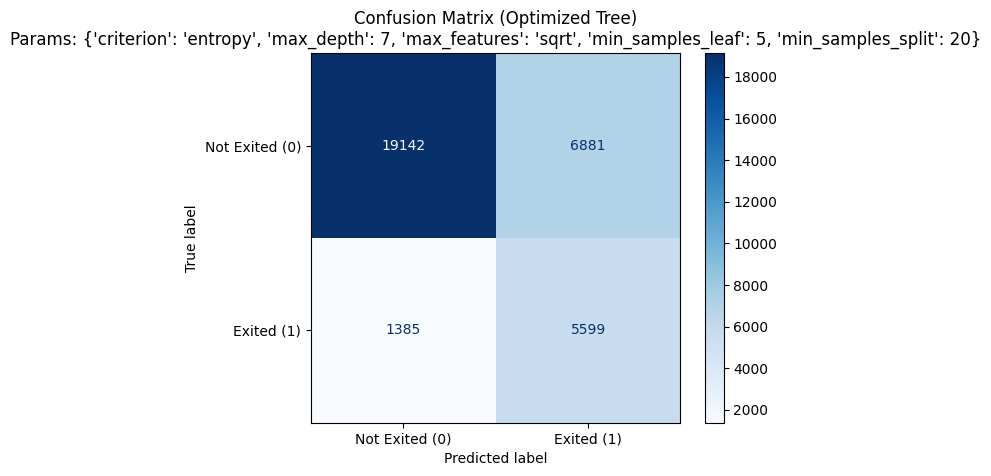

In [88]:
ConfusionMatrixDisplay.from_estimator(
    best_dt_model,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title(f'Confusion Matrix (Optimized Tree)\nParams: {grid_search.best_params_}')
plt.show()


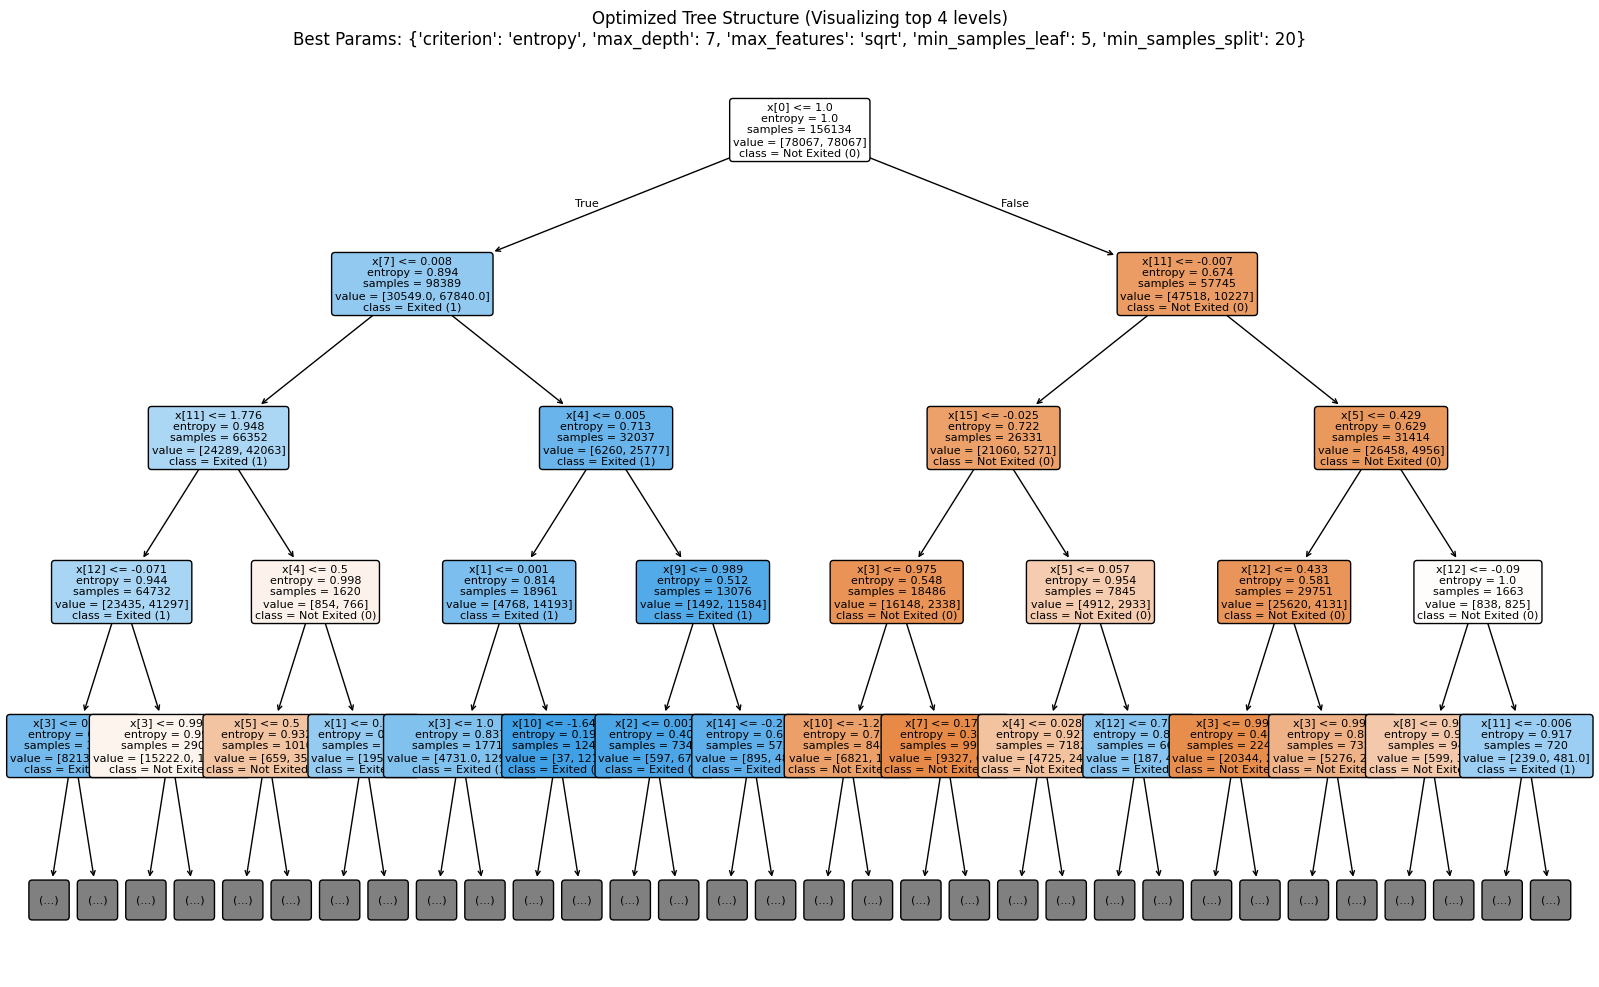

In [89]:
# Plot Tree Structure (limit depth for readability)
plt.figure(figsize=(20, 12))
plot_tree(
    best_dt_model,
    filled=True,
    rounded=True,
    class_names=['Not Exited (0)', 'Exited (1)'],
    # feature_names=X_train_smote.columns, # Uncomment if available
    fontsize=8,
    max_depth=4  # Limit visualization depth to 4 for readability
)
plt.title(f"Optimized Tree Structure (Visualizing top 4 levels)\nBest Params: {grid_search.best_params_}")
plt.show()

So we will keep the best model

In [90]:
model_dt = best_dt_model

## 2. Ensemble models

### RandomForestClassifier

In [91]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=4,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

model_rf.fit(X_train_smote, y_train_smote)

y_pred_rf = model_rf.predict(X_val_scaled)

print("\nClassification Report (Random Forest)")
print(classification_report(y_val, y_pred_rf, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1))


Classification Report (Random Forest)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.79      0.85     26023
    Exited (1)       0.49      0.77      0.60      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007


F2-Score
0.6945086556737042


In [92]:
train_score = fbeta_score(y_train_smote, model_rf.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8063
fbeta Val   : 0.6945
Gap   : 0.1118


There is still the slight overfitting, we feel like with our dataset it is pratically impossible to not overfit (it probably lacks of differents columns despit our feature engineering)

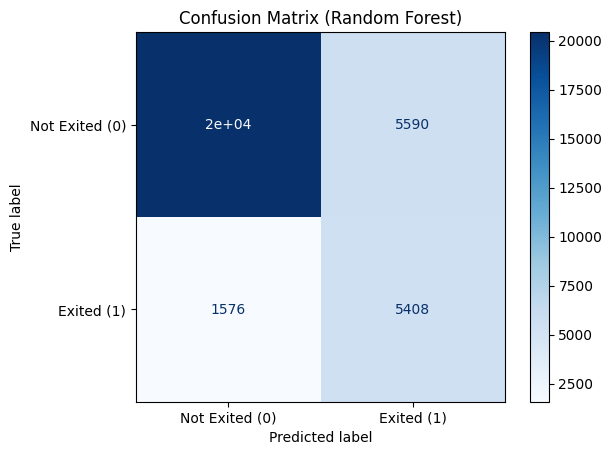

In [93]:
ConfusionMatrixDisplay.from_estimator(
    model_rf,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [94]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    # The number of trees in the forest. More trees increase stability and performance but slow down training.
    'max_depth': [10, 20],
    # Restricting depth prevents individual trees from overfitting.
    'min_samples_split': [2, 5],
    # Higher values prevent trees from growing too specific to the training data.
    'min_samples_leaf': [2, 4],
    # Ensures leaf nodes are not too small, aiding generalization.
    'max_features': ['log2']
    # Using log2 features forces the trees to be more diverse (decorrelated), which improves the ensemble performance.
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=8,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_smote, y_train_smote)

print("Best parameters found:")
print(random_search.best_params_)


best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_val_scaled)

print("\nClassification Report (Random Forest Optimized)")
print(classification_report(y_val, y_pred_rf,target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

Classification Report (Random Forest Optimized)
                precision    recall  f1-score   support

Not Exited (0)       0.91      0.84      0.88     26023
    Exited (1)       0.55      0.71      0.62      6984

      accuracy                           0.82     33007
     macro avg       0.73      0.78      0.75     33007
  weighted avg       0.84      0.82      0.82     33007


F2-Score
0.6684542672191978


In [95]:
train_score = fbeta_score(y_train_smote, best_rf.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.9216
fbeta Val   : 0.6685
Gap   : 0.2531


The overfitting is bigger

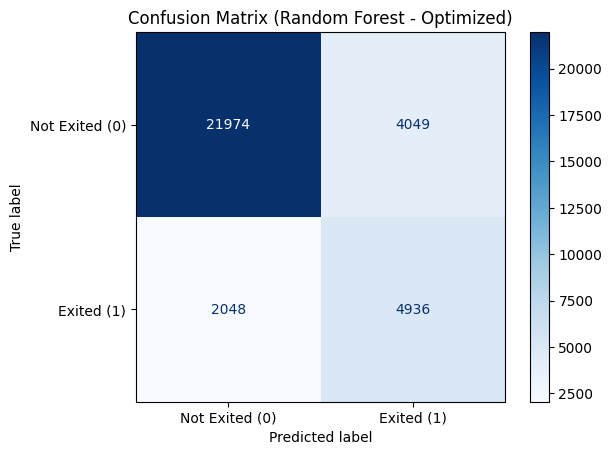

In [96]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Random Forest - Optimized)')
plt.show()

So the best model is the initial model

In [97]:
model_rf = model_rf

C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\1032394399.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


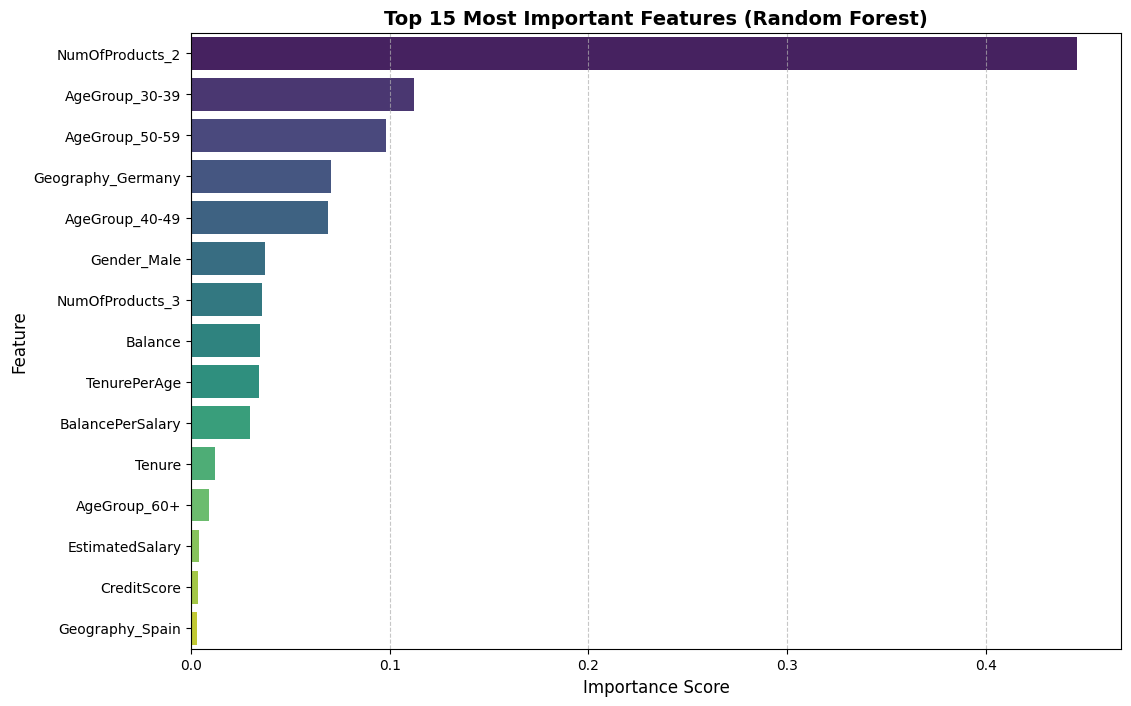

              Feature  Importance
0     NumOfProducts_2    0.445772
3      AgeGroup_30-39    0.111971
5      AgeGroup_50-59    0.098104
7   Geography_Germany    0.070658
4      AgeGroup_40-49    0.068901
9         Gender_Male    0.037262
1     NumOfProducts_3    0.035472
12            Balance    0.034893
14       TenurePerAge    0.033970
15   BalancePerSalary    0.029612


In [98]:
importances = model_rf.feature_importances_ 
feature_names = all_feature_names

feature_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df.head(15),
    palette='viridis'
)

plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_imp_df.head(10))

Here we wanted to see if our feature engineering was impactful or not, and the answer is yes! 
- The differents classes of the column NumOfProducts are really impactful, this is actually logical. Customers with 2 products are typically the most stable and least likely to churn (they are "engaged" but not "over-saturated"). Customers with 1 product or 3+ products are much more volatile. Our model has correctly identified that knowing if a customer has "Exactly 2 Products" is the best way to split the data immediately
- AgeGroup this column (created in our feature engineering) is important, this was to be expected because the Age column had a strong correlation with the target column
- we can also see that TenurePerAge and BalancePerSalary are high in th ranking!

We won't plot this graphic everytime, it is not really necessary but iw was interessant to see here that our feature engineering worked and helped.

### XGBoost (eXtreme Gradient Boosting)

In [99]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_val_scaled, y_val)],
    verbose=False
)

y_pred_xgb = model_xgb.predict(X_val_scaled)

print("\nClassification Report (XGBoost - Validation)")
print(classification_report(y_val, y_pred_xgb, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_xgb, beta=2, pos_label=1))


Classification Report (XGBoost - Validation)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.76      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.73     33007
  weighted avg       0.84      0.79      0.81     33007


F2-Score
0.6926660420570476


In [100]:
train_score = fbeta_score(y_train_smote, model_xgb.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_xgb, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8208
fbeta Val   : 0.6927
Gap   : 0.1281


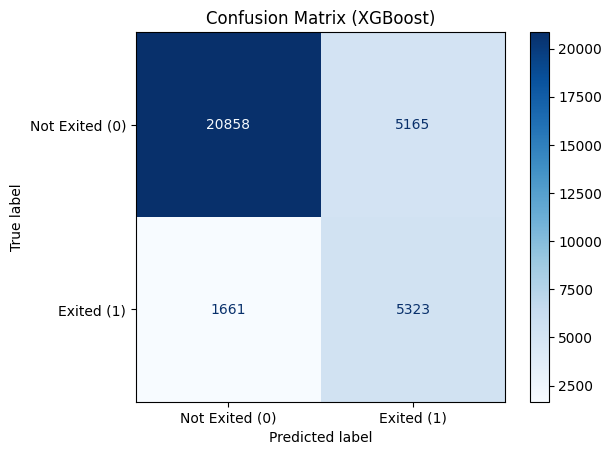

In [101]:
ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (XGBoost)')
plt.show()

In [102]:
param_grid_xgb = {
    'max_depth': [3, 4, 5],
    # Boosting models are prone to overfitting. We keep trees shallow (3-5) because they learn sequentially, correcting errors of previous trees.
    'learning_rate': [0.01, 0.05, 0.1],
    # Also known as 'eta'. Lower values (0.01) make the model robust but require more trees (n_estimators) to converge.
    'n_estimators': [100, 200, 300],
    # Number of boosting rounds. We test up to 300 to give the model enough capacity to learn with lower learning rates.
    'gamma': [0, 0.1, 0.5],
    # Minimum loss reduction required to make a further partition on a leaf node of the tree.
    # Acts as a regularization parameter to control complexity.
    'subsample': [0.8, 1.0]
    # Subsample ratio of the training instances. 0.8 means training on 80% of data (randomly) prevents overfitting.
}

xgb_model = XGBClassifier(
    random_state=42,
    subsample=0.8,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)


grid_xgb.fit(X_train_smote, y_train_smote)

print("\Bests parameters found:")
print(grid_xgb.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:32:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


\Bests parameters found:
{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


In [103]:
best_xgb = grid_xgb.best_estimator_
y_pred_val_xgb = best_xgb.predict(X_val_scaled)

print("\nClassification Report (XGBoost Tuned - Validation)")
print(classification_report(y_val, y_pred_val_xgb, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_xgb, beta=2, pos_label=1))


Classification Report (XGBoost Tuned - Validation)
                precision    recall  f1-score   support

Not exited (0)       0.92      0.85      0.88     26023
    Exited (1)       0.56      0.71      0.63      6984

      accuracy                           0.82     33007
     macro avg       0.74      0.78      0.75     33007
  weighted avg       0.84      0.82      0.83     33007


F2-Score
0.6767243718456613


In [104]:
train_score = fbeta_score(y_train_smote, best_xgb.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_xgb, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8506
fbeta Val   : 0.6767
New Gap   : 0.1739


This optimized model is less good than the first one

So the best model is the initial one:

In [105]:
model_xgb = model_xgb

### LightGBM (Light Gradient Boosting Machine)

In [106]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=31,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

model_lgbm.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_val_scaled, y_val)],
    eval_metric='logloss'
)

y_pred_lgbm = model_lgbm.predict(X_val_scaled)

print("\nClassification Report (LightGBM - Validation)")
print(classification_report(y_val, y_pred_lgbm, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_lgbm, beta=2, pos_label=1))

[LightGBM] [Info] Number of positive: 78067, number of negative: 78067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 156134, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [107]:
train_score = fbeta_score(y_train_smote, model_lgbm.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_lgbm, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fbeta Train : 0.8237
fbeta Val   : 0.6895
Gap   : 0.1342


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


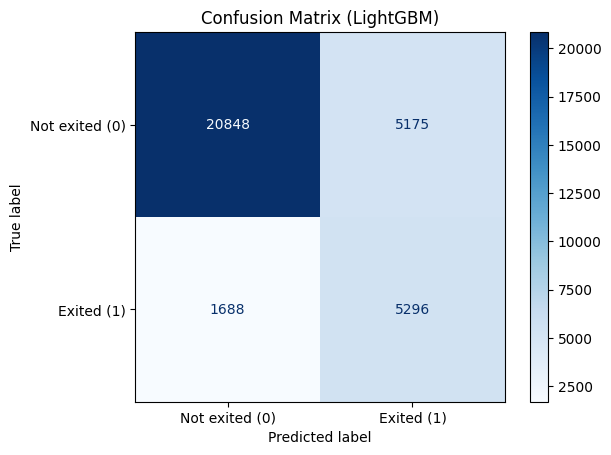

In [108]:
ConfusionMatrixDisplay.from_estimator(
    model_lgbm,
    X_val_scaled,
    y_val,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (LightGBM)')
plt.show()

In [109]:
param_grid_lgbm = {
    'num_leaves': [10, 20],
    # LightGBM uses leaf-wise growth. This is the main parameter to control complexity.
    # Keeping it low (10-20) prevents overfitting on medium datasets.
    'max_depth': [3, 5],
    # Explicitly limits the depth of the tree to avoid growing too deep.
    'learning_rate': [0.01, 0.05],
    # Slower learning rate (0.01) usually yields better generalization.
    'n_estimators': [100, 200],
    # Number of boosted trees to fit.
    'min_child_samples': [20, 30]
    # Similar to min_samples_leaf in sklearn. Prevents overfitting. 
}

lgbm_model = LGBMClassifier(subsample=0.8, random_state=42)

grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_lgbm.fit(X_train_smote, y_train_smote)

print("\Bests parameters LightGBM:")
print(grid_lgbm.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Info] Number of positive: 78067, number of negative: 78067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 156134, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
\Bests parameters LightGBM:
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 20}


In [110]:
best_lgbm = grid_lgbm.best_estimator_
y_pred_val_lgbm = best_lgbm.predict(X_val_scaled)

print("\nClassification report")
print(classification_report(y_val, y_pred_val_lgbm, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_lgbm, beta=2, pos_label=1))


Classification report
                precision    recall  f1-score   support

Not exited (0)       0.92      0.84      0.88     26023
    Exited (1)       0.55      0.73      0.62      6984

      accuracy                           0.81     33007
     macro avg       0.73      0.78      0.75     33007
  weighted avg       0.84      0.81      0.82     33007


F2-Score
0.6829654690940337


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [111]:
train_score = fbeta_score(y_train_smote, best_lgbm.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_lgbm, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fbeta Train : 0.8478
fbeta Val   : 0.6830
New Gap   : 0.1648


So the best model is the initial one:

In [112]:
model_lgbm = model_lgbm

### VotingClassifier and StackingClassifier

#### VotingClassifier 1
First attempt using three hyperparameter-tuned models (Logistic Regression, Decision Tree, and LightGBM)

In [113]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', model_lr),
        ('dt', model_dt),
        ('lgbm', model_lgbm)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_smote, y_train_smote)

y_pred_voting = voting_clf.predict(X_val_scaled)

print("\nVoting Classifier Report")
print(classification_report(y_val, y_pred_voting, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting, beta=2, pos_label=1))


Voting Classifier Report
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.78      0.85     26023
    Exited (1)       0.49      0.78      0.60      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007


F2-Score
0.6986413530179362


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### StackingClassifier 1
First attempt using three hyperparameter-tuned models (Logistic Regression, Decision Tree, and LightGBM)

In [114]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', model_lr),
        ('dt', model_dt),
        ('lgbm', model_lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf.fit(X_train_smote, y_train_smote)

y_pred_stack = stacking_clf.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stack, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stack, beta=2, pos_label=1))


Classification Report
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.81      0.86     26023
    Exited (1)       0.51      0.75      0.61      6984

      accuracy                           0.80     33007
     macro avg       0.72      0.78      0.73     33007
  weighted avg       0.84      0.80      0.81     33007


F2-Score
0.6832974647000157


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### VotingClassifier 2
First attempt using five hyperparameter-tuned models (Logistic Regression, Decision Tree, Random Forest,  LightGBM and XGBoost)

In [115]:
voting_clf_5 = VotingClassifier(
    estimators=[
        ('lr', model_lr),
        ('dt', model_dt),
        ('rf', model_rf),
        ('lgbm', model_lgbm),
        ('xgb', model_xgb)
    ],
    voting='hard',
    n_jobs=-1
)

voting_clf_5.fit(X_train_smote, y_train_smote)

y_pred_voting_5 = voting_clf_5.predict(X_val_scaled)

print("\nVoting Classifier (5 models)")
print(classification_report(y_val, y_pred_voting_5, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stack, beta=2, pos_label=1))


Voting Classifier (5 models)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.79      0.85     26023
    Exited (1)       0.50      0.77      0.60      6984

      accuracy                           0.79     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.79      0.80     33007


F2-Score
0.6832974647000157


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### StackingClassifier 2
First attempt using five hyperparameter-tuned models (Logistic Regression, Decision Tree, Random Forest,  LightGBM and XGBoost)

In [116]:
stacking_clf_5 = StackingClassifier(
    estimators=[
        ('lr', model_lr),
        ('dt', model_dt),
        ('rf', model_rf),
        ('lgbm', model_lgbm),
        ('xgb', model_xgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_5.fit(X_train_smote, y_train_smote)

y_pred_stacking_5 = stacking_clf_5.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_5, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_5, beta=2, pos_label=1))


Classification Report
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.81      0.86     26023
    Exited (1)       0.51      0.74      0.61      6984

      accuracy                           0.80     33007
     macro avg       0.72      0.78      0.74     33007
  weighted avg       0.84      0.80      0.81     33007


F2-Score
0.682296323568085


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### VotingClassifier 3
Second attempt using three hyperparameter-tuned models (Random Forest, XGBoost and LightGBM)

In [117]:
voting_clf_3 = VotingClassifier(
    estimators=[
        ('rf', model_rf),
        ('xgb', model_xgb),
        ('lgbm', model_lgbm)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf_3.fit(X_train_smote, y_train_smote)

y_pred_voting_3 = voting_clf_3.predict(X_val_scaled)

print("\nVoting Classifier (3 Models: RF + XGB + LGBM)")
print(classification_report(y_val, y_pred_voting_3, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting_3, beta=2, pos_label=1))


Voting Classifier (3 Models: RF + XGB + LGBM)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.50      0.76      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.79      0.80     33007


F2-Score
0.6913650760683316


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### StackingClassifier 3
Second attempt using three hyperparameter-tuned models (Random Forest, XGBoost and LightGBM)

In [118]:
stacking_clf_3 = StackingClassifier(
    estimators=[
        ('rf', model_rf),
        ('xgb', model_xgb),
        ('lgbm', model_lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_3.fit(X_train_smote, y_train_smote)

y_pred_stacking_3 = stacking_clf_3.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_3, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_3, beta=2, pos_label=1))


Classification Report
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.81      0.86     26023
    Exited (1)       0.52      0.74      0.61      6984

      accuracy                           0.80     33007
     macro avg       0.72      0.78      0.74     33007
  weighted avg       0.84      0.80      0.81     33007


F2-Score
0.6834144416677628


c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4. Neural Networks Models

### MLP (Multi Layer Perceptron)

In [119]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    random_state=42,
    max_iter=1000,
    early_stopping=True # To avoid too much overfitting
)

model_mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = model_mlp.predict(X_val_scaled)

print("\nClassification Report (Basic MLP)")
print(classification_report(y_val, y_pred_mlp, target_names=['No exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_mlp, beta=2, pos_label=1))


Classification Report (Basic MLP)
               precision    recall  f1-score   support

No exited (0)       0.93      0.80      0.86     26023
   Exited (1)       0.51      0.77      0.61      6984

     accuracy                           0.79     33007
    macro avg       0.72      0.78      0.74     33007
 weighted avg       0.84      0.79      0.81     33007


F2-Score
0.6975626234279181


In [120]:
train_score = fbeta_score(y_train_smote, model_mlp.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_mlp, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8000
fbeta Val   : 0.6976
New Gap   : 0.1024


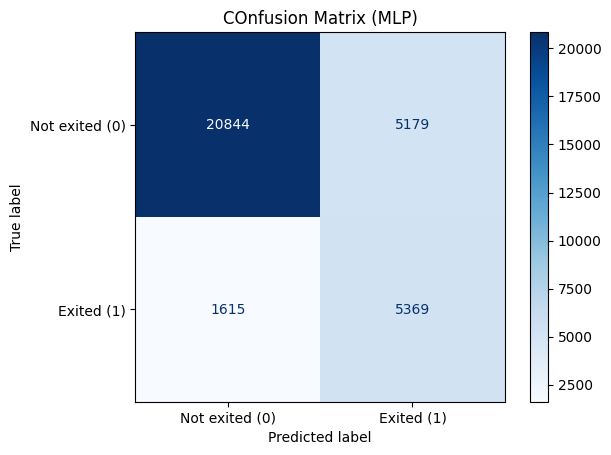

In [121]:
ConfusionMatrixDisplay.from_estimator(
    model_mlp,
    X_val_scaled,
    y_val,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('COnfusion Matrix (MLP)')
plt.show()

In [122]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True)

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_mlp.fit(X_train_smote, y_train_smote)

print("\nBests parameters MLP:")
print(grid_mlp.best_params_)

best_mlp = grid_mlp.best_estimator_
y_pred_val_mlp = best_mlp.predict(X_val_scaled)

print("\nClassification Report (Tuned MLP)")
print(classification_report(y_val, y_pred_val_mlp, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_mlp, beta=2, pos_label=1))

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Bests parameters MLP:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}

Classification Report (Tuned MLP)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.81      0.86     26023
    Exited (1)       0.51      0.77      0.62      6984

      accuracy                           0.80     33007
     macro avg       0.72      0.79      0.74     33007
  weighted avg       0.84      0.80      0.81     33007


F2-Score
0.6977289912132036


In [123]:
train_score = fbeta_score(y_train_smote, best_mlp.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_mlp, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.7946
fbeta Val   : 0.6977
New Gap   : 0.0969


So the best mlp score is the optimized one

In [124]:
model_mlp = best_mlp

#### VotingClassifier 4
Third attempt using three hyperparameter-tuned models with our bests models so far: Logistic Regression, SVM and MLP

In [125]:
voting_clf_mlp = VotingClassifier(
    estimators=[
        ('lr', model_lr),
        ('rf', model_rf),
        ('mlp', model_mlp)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf_mlp.fit(X_train_smote, y_train_smote)

y_pred_voting_mlp = voting_clf_mlp.predict(X_val_scaled)

print("\nVoting Classifier (RF + XGB + base MLP)")
print(classification_report(y_val, y_pred_voting_mlp, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting_mlp, beta=2, pos_label=1))


Voting Classifier (RF + XGB + base MLP)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.79      0.86     26023
    Exited (1)       0.50      0.78      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.79      0.73     33007
  weighted avg       0.84      0.79      0.80     33007


F2-Score
0.7024313442081355


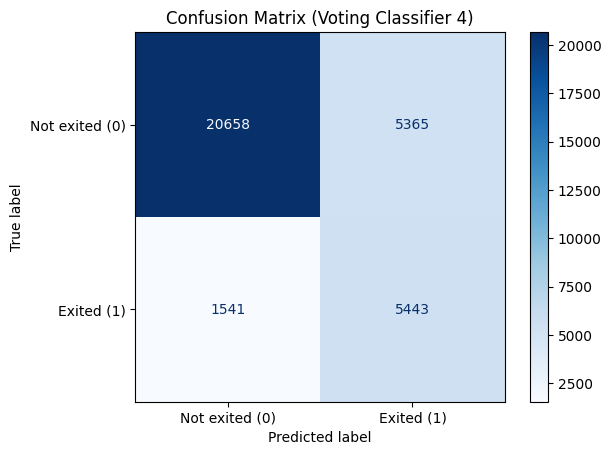

In [126]:
ConfusionMatrixDisplay.from_estimator(
    voting_clf_mlp,
    X_val_scaled,
    y_val,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Voting Classifier 4)')
plt.show()

#### StackingClassifier 4
Second attempt using three hyperparameter-tuned models with our bests models so far: Logistic Regression, SVM and MLP

In [127]:
stacking_clf_mlp = StackingClassifier(
    estimators=[
        ('lr', model_lr),
        ('rf', model_rf),
        ('mlp', model_mlp)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_mlp.fit(X_train_smote, y_train_smote)

y_pred_stacking_mlp = stacking_clf_mlp.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_mlp, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_mlp, beta=2, pos_label=1))


Classification Report
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.77      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.73     33007
  weighted avg       0.84      0.79      0.81     33007


F2-Score
0.6949491279069767


So the best Voting Classifier is the first one and the best stacking classifier is also the first one

In [128]:
# Best of the 3 first tests
model_vclf = voting_clf
model_scclf = stacking_clf_3
# Last test with the 3 best models so far
model_vclf_mlp = voting_clf_mlp
model_cclf_mlp = stacking_clf_mlp


# IX. Comparison

We chose to only represents the best model of each category

In [129]:
from sklearn.metrics import accuracy_score, recall_score

In [130]:
all_models = {
    "Logistic Regression": model_lr,
    "SVM": model_svm,
    "PCA": pipe_pca_model,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "LGBM": model_lgbm,
    "Voting Classifier": model_vclf,
    "Stacking Classifier": model_scclf,
    "MLP": model_mlp,
    "Voting Classifier optimized":model_vclf_mlp,
    "Stacking Classifier optimized":model_cclf_mlp
}


model_f2_scores = {}
model_accuracy_scores = {}
model_recall_scores = {}
models_with_internal_preprocessor = ["PCA"]

for name, model in all_models.items():

    if name in models_with_internal_preprocessor:
        X_input = X_val
    else:
        X_input = X_val_scaled

    try:
        y_pred_val = model.predict(X_input)

        f2_score_val = fbeta_score(
            y_val,
            y_pred_val,
            beta=2,
            pos_label=1,
        )
        model_f2_scores[name] = f2_score_val
        
        accuracy_val = accuracy_score(y_val, y_pred_val)
        model_accuracy_scores[name] = accuracy_val
        
        recall_val = recall_score(y_val, y_pred_val, pos_label=1)
        model_recall_scores[name] = recall_val

    except Exception as e:
        print(f"Error during the computation of the F2-score for {name}: {e}")
        model_f2_scores[name] = np.nan

c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## F2-Score

C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\4075233540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Validation F2-scores', y='Model', data=f2_scores_df, palette='viridis')


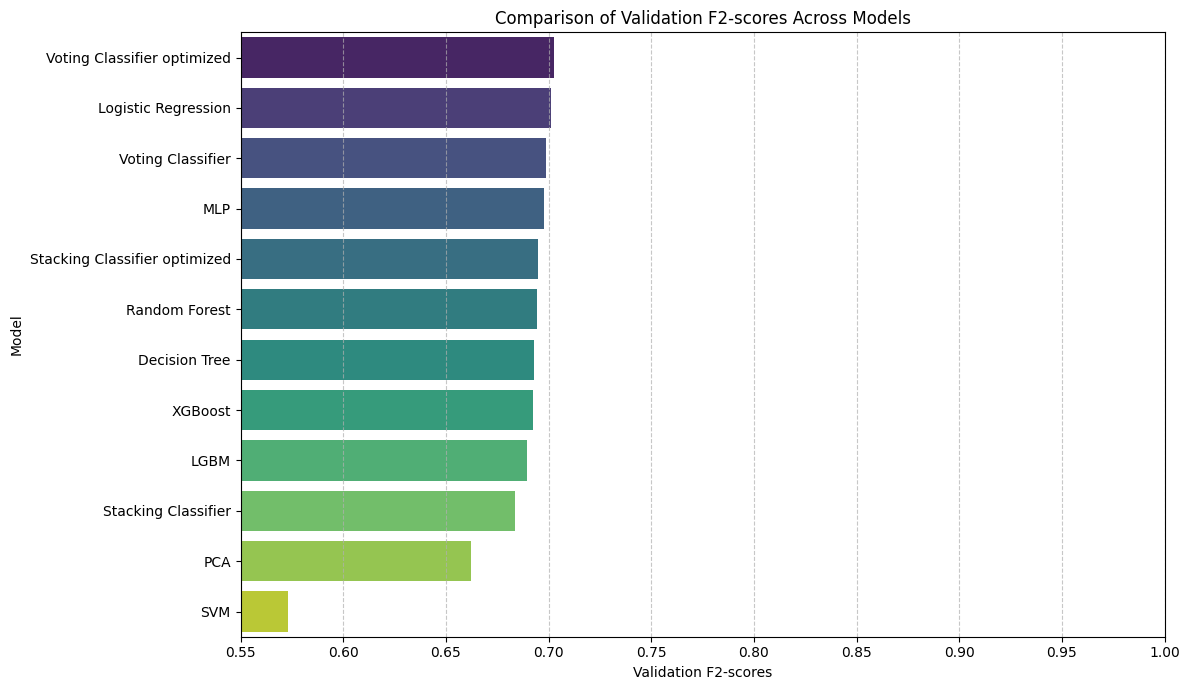

In [131]:
f2_scores_df = pd.DataFrame(model_f2_scores.items(), columns=['Model', 'Validation F2-scores'])
f2_scores_df = f2_scores_df.sort_values(by='Validation F2-scores', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Validation F2-scores', y='Model', data=f2_scores_df, palette='viridis')
plt.title('Comparison of Validation F2-scores Across Models')
plt.xlabel('Validation F2-scores')
plt.ylabel('Model')
plt.xlim(0.55, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In the end our best model for our personnalized metric F2-score is the Voting Classifier Optimized

## Other metrics

Let's see how our model is in other metrics (for knowledge and curiosity)

C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\1742090403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Validation Accuracy', y='Model', data=accuracy_score_df, palette='viridis')


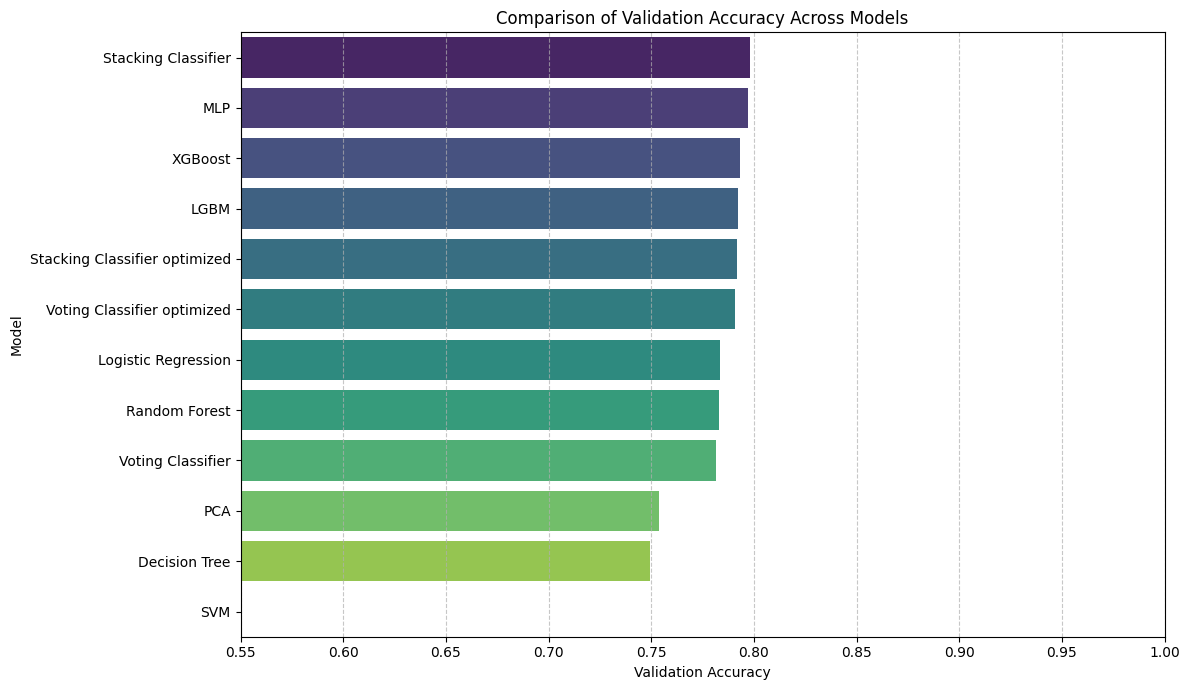

In [132]:
accuracy_score_df = pd.DataFrame(model_accuracy_scores.items(), columns=['Model', 'Validation Accuracy'])
accuracy_score_df = accuracy_score_df.sort_values(by='Validation Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Validation Accuracy', y='Model', data=accuracy_score_df, palette='viridis')
plt.title('Comparison of Validation Accuracy Across Models')
plt.xlabel('Validation Accuracy')
plt.ylabel('Model')
plt.xlim(0.55, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In the end the model with the best accuracy is the stacking classifier

C:\Users\maxim\AppData\Local\Temp\ipykernel_10676\206940464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Validation Recall', y='Model', data=recall_score_df, palette='viridis')


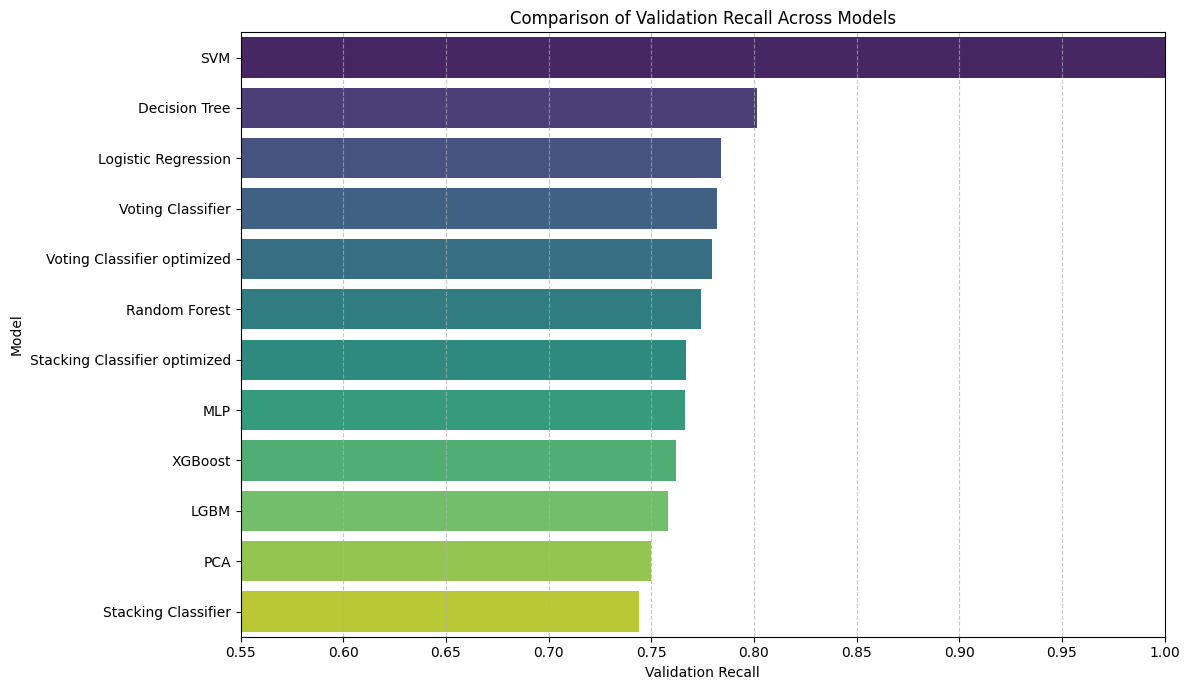

In [133]:
recall_score_df = pd.DataFrame(model_recall_scores.items(), columns=['Model', 'Validation Recall'])
recall_score_df = recall_score_df.sort_values(by='Validation Recall', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Validation Recall', y='Model', data=recall_score_df, palette='viridis')
plt.title('Comparison of Validation Recall Across Models')
plt.xlabel('Validation Recall')
plt.ylabel('Model')
plt.xlim(0.55, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

And in the end the model with the best recall is the svm (which is totally paranoiac and has a lot of false positive)

We can see that the order is not the same every time, some are best at the Accuracy but have a poor performance in the recall and vice versa (same for F2-score)

# X. Final Test on the test Data

We are going to the test our best model (i.e. Voting Classifier Optimized) on our Test Data

In [134]:
y_pred_final_test = model_vclf_mlp.predict(X_test_scaled)

print("F2-score of our best model on the test data: ", fbeta_score(y_test, y_pred_final_test, beta=2, pos_label=1))
print()
print("\nClassification Report")
print(classification_report(y_test, y_pred_final_test, target_names=['Not Exited (0)', 'Exited (1)']))

F2-score of our best model on the test data:  0.6975355130236061


Classification Report
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.77      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.74     33007
  weighted avg       0.84      0.79      0.81     33007



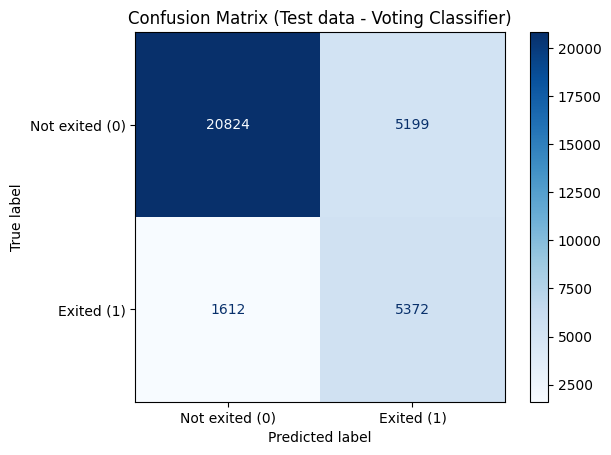

In [135]:
ConfusionMatrixDisplay.from_estimator(
    model_vclf_mlp,
    X_test_scaled,
    y_test,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test data - Voting Classifier)')
plt.show()

# XI. Conclusion

Here can see that our model classifies 10 651 clients as “High Risk Clients” (i.e. predicts that they will churn). But only around 50% of them (51% to be precise) churn for real at the end. However, our model only misses 1 605 clients that churn, it means that our model catches around 75% (77% to be precise) of the clients that will exit the bank.  
  
In a real-life scenario, this model is already helpful for a company, because even if it is not 100% accurate and a bit “paranoiac”, it helps the company to see 77% of the clients that churn. In the end, the company can try to make some new offers to try to keep all the clients that the model predicts as “High Risk”. If they do, they will reduce the number of churning clients by 77%.